<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 1 검정: BTC 가격 변동과 GPU 가격 변동의 단기/장기 관계</mark></b></span><br><br>

<b>[분석 목적]</b><br>
• 전체 GPU 가격지수의 검정용 주간 로그수익률(<b>ret_all_w['GPU_ALL']</b>)을 사용해 BTC-KRW 변동과의 단기 공변동을 검정한다.<br>
• 조교 피드백을 반영해 BTC 효과가 즉시 나타나는지, 혹은 몇 주 시차를 두고 나타나는지 <b>lag 0~8주</b>로 확인한다.<br>
• 환율(<b>fx_ret</b>)과 AI/반도체 수요 proxy(<b>nvda_ret</b>)를 통제해 BTC 효과와 외부 수요 효과를 분리한다.<br>
• 다중공선성은 <b>VIF</b>로 점검하고, 편상관관계적 해석은 <b>partial correlation + 다변량 회귀계수</b>로 보조 설명한다.<br>
• 보조적인 선행성 검정은 단순 이변량 Granger가 아니라 <b>VAR 기반 다변량 Granger causality</b>를 사용한다.<br>
• 장기 관계는 가격 level이 아니라 <b>log index / log price level</b>을 이용해 ADF, Engle-Granger, ECM 순서로 확인한다.<br><br>

<b>[ETC-KRW 보조 EDA 추가 이유]</b><br>
BTC는 현대 시점에서 GPU 채굴 직접 수요라기보다 암호화폐 시장심리 proxy에 가깝다. 반면 <b>ETC-KRW</b>는 Ethereum Classic으로, GPU 채굴과의 연결 가능성이 상대적으로 더 직접적일 수 있다. 다만 시장 규모와 유동성 측면에서 BTC보다 대표성이 약하므로, 본 가설의 메인 설명변수로 넣지 않고 <b>도메인 방어용 보조 EDA</b>로만 확인한다.<br><br>

<b>[도메인 방어 논리]</b><br>
본 기간은 2024~2026년으로 ETH Merge 이후이다. 따라서 BTC는 GPU 채굴 수요의 직접 원인이라기보다 <b>암호화폐 시장 심리와 위험자산 수요를 대표하는 macro crypto proxy</b>로 해석한다. 직접 채굴 수요 효과를 주장하지 않고, BTC 시장 변동이 GPU 가격지수와 통계적으로 동행/선행하는지를 검정한다.<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: 단기 검정은 ret_w, 장기 검정은 index level, BTC 시차 효과는 distributed lag regression으로 본다. ETC-KRW는 메인 검정이 아니라 보조 EDA로만 사용한다.</b></span>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.tsa.stattools import adfuller, coint

from statsmodels.tsa.api import VAR

from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.stats.diagnostic import acorr_ljungbox

OUT = Path("outputs")

H1_OUT = OUT / "hypo1"
H1_OUT.mkdir(parents=True, exist_ok=True)

MAX_LAG = 8      # BTC 반영 시차: 0~8주
HAC_LAG = 4      # Newey-West HAC 표준오차 lag

GPU_RET_COL = "GPU_ALL"
MKT_RET_COLS = ["btc_krw_ret", "fx_ret", "nvda_ret", "nasdaq_ret", "sox_ret"]

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "MalGun Gothic"
plt.rcParams["axes.unicode_minus"] = False

import re as _re
from datetime import datetime as _dt

FIG_DIR = Path("output_pic") / "hypo_1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _safe_fname(text, max_len=120):
    text = str(text).strip()
    text = _re.sub(r"[\\/:*?\"<>|]+", "_", text)
    text = _re.sub(r"\s+", "_", text)
    text = _re.sub(r"_+", "_", text).strip("._ ")
    if not text:
        text = "plot"
    return text[:max_len]

def _infer_title(fig=None):
    fig = fig or plt.gcf()
    if getattr(fig, "_suptitle", None) is not None:
        t = fig._suptitle.get_text()
        if t:
            return t
    for ax in fig.axes:
        t = ax.get_title()
        if t:
            return t
    for ax in fig.axes:
        ylabel = ax.get_ylabel()
        xlabel = ax.get_xlabel()
        if ylabel or xlabel:
            return f"{ylabel}_vs_{xlabel}".strip("_vs_")
    return "plot_" + _dt.now().strftime("%Y%m%d_%H%M%S")

def save_plot(name=None, folder=None, dpi=300):
    folder = Path(folder) if folder is not None else FIG_DIR
    folder.mkdir(parents=True, exist_ok=True)
    fig = plt.gcf()
    title = name or _infer_title(fig)
    stem = _safe_fname(title)
    path = folder / f"{stem}.png"
    i = 2
    while path.exists():
        path = folder / f"{stem}_{i:02d}.png"
        i += 1
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved plot] {path}")
    return path

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Plot 저장 경로 및 해석 기준</mark></b></span><br><br>
<b>[자동 저장]</b><br>
Hypo 1에서 생성되는 모든 plot은 상대경로 <code>output_pic/hypo_1/</code>에 자동 저장된다. 저장 파일명은 plot title을 기반으로 만든다.<br><br>
<b>[판단 기준]</b><br>
Hypo 1은 개별 lag 하나의 유의성보다 BTC lag 0~8주의 공동 유의성, VAR Granger의 예측적 선행성, Engle-Granger/ECM의 장기 관계를 함께 본다. 따라서 특정 plot에서 일시적 신호가 보여도 최종 결론은 공동검정과 강건성 결과를 기준으로 해석한다.
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0. GPU output과 외부 시장변수 로드</mark></b></span><br><br>
<b>[왜 이 과정이 필요한가]</b><br>
Hypothesis 1의 단기 검정은 이미 만들어둔 <b>ret_all_w['GPU_ALL']</b>을 사용한다. 이 값은 Chain Matched Jevons Index에서 나온 전체 GPU 시장의 주간 로그수익률이므로, 가격 전처리나 0값 처리 과정을 다시 반복하지 않는다.<br><br>
외부 시장변수는 yfinance에서 불러온 뒤 GPU output과 같은 <b>W-SUN 주간 단위</b>로 맞춘다. 다만 BTC/ETC는 주말에도 거래되고 NVDA/환율은 주말 거래가 없으므로, 특정 요일 종가만 쓰면 미세한 lead-lag 불일치가 생길 수 있다. 따라서 여기서는 <b>주간 평균 log level의 차분</b>을 사용해 주간 수익률을 만든다.<br><br>
<b>[해석 기준]</b><br>
이 셀의 목적은 검정이 아니라 분석 단위 정렬이다. 이후 모든 단기 검정은 <b>weekly log return</b>, 장기 검정은 <b>weekly log level</b>을 기준으로 수행한다.
</div>

ret_all_w


,CPU_ALL,GPU_ALL,RAM_ALL
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,-0.001478,0.002189,0.002896
2024-03-17,0.000508,0.003092,0.001473
2024-03-24,0.000673,0.002050,-0.003016
2024-03-31,0.001044,0.001093,-0.001508


market weekly returns


,btc_krw_ret,etc_krw_ret,fx_ret,nvda_ret,nasdaq_ret,sox_ret
Date,,,,,,
2024-03-03,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-10,0.066505,0.110523,-0.005180,0.067045,-0.010374,0.013343
2024-03-17,0.040157,-0.062324,-0.010337,0.009760,0.000344,-0.027993
2024-03-24,-0.056947,-0.123070,0.014201,0.021430,0.011170,-0.009424
2024-03-31,0.075551,0.093258,0.008682,0.013723,0.004668,0.015417


market weekly log levels


Ticker,btc_krw,etc_krw,usdkrw,nvda,nasdaq,sox
Date,,,,,,
2024-03-03,18.237997,10.680341,7.196836,4.409505,9.697382,8.503009
2024-03-10,18.304502,10.790864,7.191656,4.476550,9.687008,8.516352
2024-03-17,18.344659,10.728540,7.181319,4.486310,9.687352,8.488359
2024-03-24,18.287712,10.605470,7.195521,4.507740,9.698523,8.478935
2024-03-31,18.363263,10.698728,7.204203,4.521463,9.703191,8.494352


saved: outputs\mkt_w.csv outputs\mkt_log_level_w.csv
[saved plot] output_pic\hypo_1\BTC-KRW_and_ETC-KRW_weekly_log_returns.png


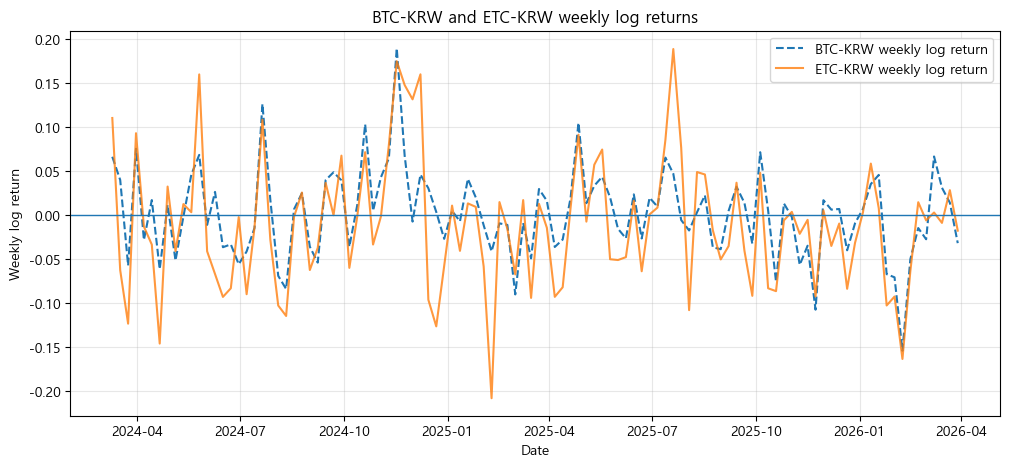

In [2]:
ret_all_w = (
    pd.read_csv(OUT / "ret_all_w.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)

idx_all_w = (
    pd.read_csv(OUT / "idx_all_w.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)

import yfinance as yf

MKT_TICKERS = {
    "BTC-KRW": "btc_krw",
    "ETC-KRW": "etc_krw",
    "KRW=X": "usdkrw",
    "NVDA": "nvda",
    "^IXIC": "nasdaq",
    "^SOX": "sox",
}

START_DATE = "2024-03-01"
END_DATE = "2026-03-31"

mkt_px = yf.download(
    list(MKT_TICKERS.keys()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)["Close"].rename(columns=MKT_TICKERS)

WEEKLY_FREQ = "W-SUN"

mkt_log_level_w = np.log(mkt_px).resample(WEEKLY_FREQ).mean()
mkt_log_level_w = mkt_log_level_w.loc[pd.to_datetime(START_DATE):pd.to_datetime(END_DATE)]

mkt_w = pd.DataFrame(index=mkt_log_level_w.index)
mkt_w["btc_krw_ret"] = mkt_log_level_w["btc_krw"].diff()
mkt_w["etc_krw_ret"] = mkt_log_level_w["etc_krw"].diff()
mkt_w["fx_ret"] = mkt_log_level_w["usdkrw"].diff()
mkt_w["nvda_ret"] = mkt_log_level_w["nvda"].diff()
mkt_w["nasdaq_ret"] = mkt_log_level_w["nasdaq"].diff()
mkt_w["sox_ret"] = mkt_log_level_w["sox"].diff()

mkt_w.to_csv(OUT / "mkt_w.csv")
mkt_log_level_w.to_csv(OUT / "mkt_log_level_w.csv")

print("ret_all_w")
display(ret_all_w.head())

print("market weekly returns")
display(mkt_w.head())

print("market weekly log levels")
display(mkt_log_level_w.head())

print("saved:", OUT / "mkt_w.csv", OUT / "mkt_log_level_w.csv")

plt.figure(figsize=(12, 5))
plt.plot(mkt_w.index, mkt_w["btc_krw_ret"], linestyle="--", label="BTC-KRW weekly log return")
plt.plot(mkt_w.index, mkt_w["etc_krw_ret"], alpha=0.8, label="ETC-KRW weekly log return")
plt.axhline(0, linewidth=1)
plt.title("BTC-KRW and ETC-KRW weekly log returns")
plt.xlabel("Date")
plt.ylabel("Weekly log return")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0-1. ETC-KRW 보조 EDA</mark></b></span><br><br>
<b>[왜 ETC-KRW를 따로 보는가]</b><br>
BTC는 2024~2026년 분석기간에서 GPU 채굴 수요의 직접 변수라고 보기 어렵다. 그래서 BTC는 암호화폐 시장심리 또는 위험자산 선호를 대표하는 proxy로 사용한다. 반면 <b>ETC-KRW</b>는 GPU 채굴 가능성과 더 직접적으로 연결될 수 있으므로, 발표에서 “왜 BTC를 썼는가?”라는 질문에 대비하기 위한 <b>도메인 보조 EDA</b>로 확인한다.<br><br>
<b>[왜 메인 회귀에는 넣지 않는가]</b><br>
ETC는 BTC보다 시장 규모와 대표성이 작고, 본 가설은 BTC가 암호화폐 시장 전체 심리 proxy로 작동하는지를 검정하는 구조이다. 따라서 ETC는 메인 설명변수로 넣기보다, BTC와 ETC가 얼마나 같이 움직이는지, ETC가 GPU 수익률과 어떤 lag에서 더 강한 단순 상관을 보이는지를 확인하는 보조 분석으로 둔다.<br><br>
<b>[실행 후 해석]</b><br>
• BTC-ETC 상관이 높으면 BTC가 암호화폐 시장 전체 변동을 대표한다는 방어 논리가 강화된다.<br>
• ETC-GPU lag 상관이 BTC-GPU보다 훨씬 강하면, 보고서에서 “BTC보다 GPU-mining coin proxy가 더 직접적인 대안일 수 있다”는 한계로 적는다.<br>
• ETC-GPU 관계도 약하면, post-Merge 이후 GPU 가격은 채굴 수요보다 AI/환율/제품주기 요인의 영향을 더 받을 수 있다는 해석이 가능하다.
</div>

BTC-KRW vs ETC-KRW return correlation
0.7457
ETC-KRW lag correlation with GPU return


,lag_week,corr_gpu_etc,n
0,0,-0.1926,105
1,1,-0.1022,104
2,2,0.0366,103
3,3,0.0358,102
4,4,0.0271,101
5,5,0.0479,100
6,6,0.0203,99
7,7,0.0463,98
8,8,0.0162,97


ETC-KRW EDA summary


,metric,value,interpretation
0,corr_btc_etc_return,0.745652,BTC-KRW와 ETC-KRW가 같은 crypto sentiment를 공유하는지 확인
1,max_abs_corr_gpu_etc_lag_week,0.000000,GPU return과 ETC-KRW lag return의 절대상관이 가장 큰 시차
2,max_abs_corr_gpu_etc_value,-0.192636,해당 시차에서의 GPU-ETC 단순 상관계수


[saved plot] output_pic\hypo_1\EDA_correlation_between_GPU_return_and_lagged_ETC-KRW_return.png


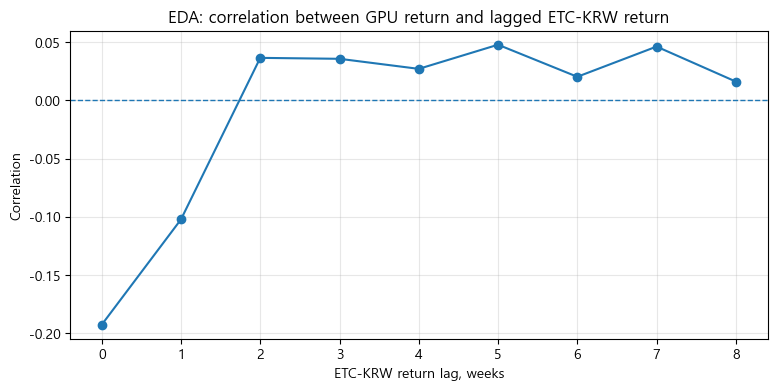

[saved plot] output_pic\hypo_1\EDA_8-week_rolling_correlation_between_BTC-KRW_and_ETC-KRW_returns.png


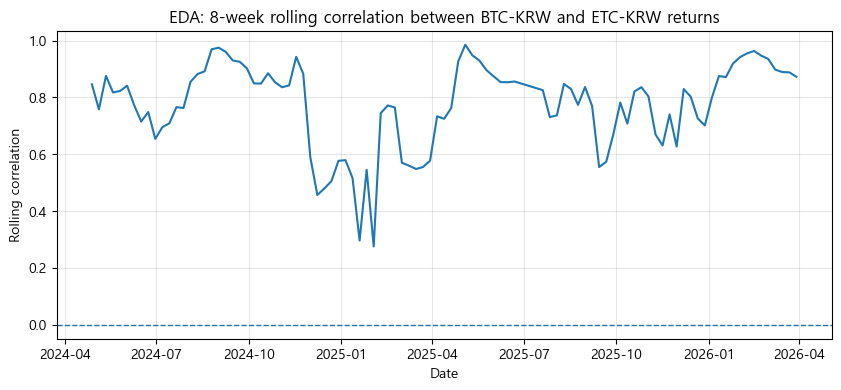

In [3]:
etc_eda = (
    ret_all_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_ret"})
    .join(mkt_w[["btc_krw_ret", "etc_krw_ret"]], how="inner")
    .dropna()
    .copy()
)

crypto_corr = etc_eda[["btc_krw_ret", "etc_krw_ret"]].corr().loc["btc_krw_ret", "etc_krw_ret"]

etc_lag_rows = []
for k in range(MAX_LAG + 1):
    col = f"etc_krw_ret_l{k}"
    etc_eda[col] = etc_eda["etc_krw_ret"].shift(k)
    temp = etc_eda[["gpu_ret", col]].dropna()
    etc_lag_rows.append({
        "lag_week": k,
        "corr_gpu_etc": temp["gpu_ret"].corr(temp[col]),
        "n": len(temp),
    })

etc_lag_corr = pd.DataFrame(etc_lag_rows)
etc_max_row = etc_lag_corr.loc[etc_lag_corr["corr_gpu_etc"].abs().idxmax()]

etc_eda_summary = pd.DataFrame([
    {
        "metric": "corr_btc_etc_return",
        "value": crypto_corr,
        "interpretation": "BTC-KRW와 ETC-KRW가 같은 crypto sentiment를 공유하는지 확인",
    },
    {
        "metric": "max_abs_corr_gpu_etc_lag_week",
        "value": int(etc_max_row["lag_week"]),
        "interpretation": "GPU return과 ETC-KRW lag return의 절대상관이 가장 큰 시차",
    },
    {
        "metric": "max_abs_corr_gpu_etc_value",
        "value": float(etc_max_row["corr_gpu_etc"]),
        "interpretation": "해당 시차에서의 GPU-ETC 단순 상관계수",
    },
])

print("BTC-KRW vs ETC-KRW return correlation")
print(round(crypto_corr, 4))

print("ETC-KRW lag correlation with GPU return")
display(etc_lag_corr.round(4))

print("ETC-KRW EDA summary")
display(etc_eda_summary)

etc_lag_corr.to_csv(H1_OUT / "etc_lag.csv", index=False)
etc_eda_summary.to_csv(H1_OUT / "etc_sum.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(etc_lag_corr["lag_week"], etc_lag_corr["corr_gpu_etc"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("EDA: correlation between GPU return and lagged ETC-KRW return")
plt.xlabel("ETC-KRW return lag, weeks")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

rolling_corr = etc_eda["btc_krw_ret"].rolling(8).corr(etc_eda["etc_krw_ret"])
plt.figure(figsize=(10, 4))
plt.plot(rolling_corr.index, rolling_corr)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("EDA: 8-week rolling correlation between BTC-KRW and ETC-KRW returns")
plt.xlabel("Date")
plt.ylabel("Rolling correlation")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1. Hypo 1 단기 검정용 데이터셋 구성</mark></b></span><br><br>
<b>[왜 이 데이터셋을 만드는가]</b><br>
단기 관계 검정에서는 가격 level을 그대로 쓰면 추세 때문에 허위 상관이 생길 수 있다. 따라서 이미 output으로 만들어진 <b>GPU_ALL 주간 로그수익률</b>을 종속변수로 사용하고, BTC-KRW 수익률의 현재값과 lag 값을 설명변수로 사용한다.<br><br>
<b>[통제변수 의미]</b><br>
• <b>fx_ret</b>: GPU 가격이 원화 기준이므로 환율 변동 효과를 제거한다.<br>
• <b>nvda_ret</b>: AI/반도체 수요가 BTC와 GPU 가격을 동시에 움직이는 교란 가능성을 통제한다.<br>
• <b>gpu_ret_l1</b>: GPU 가격 자체의 단기 관성을 통제한다.<br><br>
<b>[해석 기준]</b><br>
이후 BTC lag 계수는 환율, NVDA, GPU 자기시차의 영향을 제거한 뒤 남는 <b>BTC와 GPU 수익률의 조건부 관계</b>로 해석한다.
</div>

In [4]:
h1 = (
    ret_all_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_ret"})
    .join(mkt_w[MKT_RET_COLS], how="inner")
    .sort_index()
)

h1["gpu_ret_l1"] = h1["gpu_ret"].shift(1)

for k in range(MAX_LAG + 1):
    h1[f"btc_krw_ret_l{k}"] = h1["btc_krw_ret"].shift(k)

print("Hypo 1 regression dataset")
display(h1.head(12))

btc_lag_cols = [f"btc_krw_ret_l{k}" for k in range(MAX_LAG + 1)]
reg_cols = ["gpu_ret"] + btc_lag_cols + ["fx_ret", "nvda_ret", "gpu_ret_l1"]

sample_h1 = pd.DataFrame({
    "item": ["raw_join_weeks", "complete_regression_weeks"],
    "n": [len(h1), h1[reg_cols].dropna().shape[0]],
})

print("sample size check")
display(sample_h1)

h1.to_csv(H1_OUT / "reg.csv")
sample_h1.to_csv(H1_OUT / "sample.csv", index=False)

Hypo 1 regression dataset


,gpu_ret,btc_krw_ret,fx_ret,nvda_ret,nasdaq_ret,sox_ret,gpu_ret_l1,btc_krw_ret_l0,btc_krw_ret_l1,btc_krw_ret_l2,btc_krw_ret_l3,btc_krw_ret_l4,btc_krw_ret_l5,btc_krw_ret_l6,btc_krw_ret_l7,btc_krw_ret_l8
2024-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-10,0.002189,0.066505,-0.005180,0.067045,-0.010374,0.013343,NaN,0.066505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-17,0.003092,0.040157,-0.010337,0.009760,0.000344,-0.027993,0.002189,0.040157,0.066505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-24,0.002050,-0.056947,0.014201,0.021430,0.011170,-0.009424,0.003092,-0.056947,0.040157,0.066505,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-31,0.001093,0.075551,0.008682,0.013723,0.004668,0.015417,0.002050,0.075551,-0.056947,0.040157,0.066505,NaN,NaN,NaN,NaN,NaN
2024-04-07,-0.000115,-0.028035,0.003322,-0.038739,-0.007830,-0.004525,0.001093,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN,NaN,NaN,NaN
2024-04-14,0.000292,0.017280,0.005436,-0.009952,0.001677,-0.007794,-0.000115,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN,NaN,NaN
2024-04-21,0.002427,-0.061172,0.018837,-0.047657,-0.038052,-0.058999,0.000292,-0.061172,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN,NaN
2024-04-28,-0.000934,0.011898,-0.006040,-0.014769,0.001112,-0.001062,0.002427,0.011898,-0.061172,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505,NaN
2024-05-05,-0.000639,-0.051308,0.000705,0.047370,0.010665,0.023249,-0.000934,-0.051308,0.011898,-0.061172,0.017280,-0.028035,0.075551,-0.056947,0.040157,0.066505


sample size check


,item,n
0,raw_join_weeks,109
1,complete_regression_weeks,96


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1-1. Lag 변수 결측 전파 점검</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
BTC lag 0~8주를 만들면 앞쪽 주차는 구조적으로 결측이 생기고, GPU 수익률이나 시장변수 결측이 있으면 회귀 표본에서 추가로 제외된다. 시차 검정에서 결측을 forward fill하면 미래 정보를 과거에 섞거나 실제 관측되지 않은 수익률을 만들 위험이 있으므로, 본 분석에서는 <b>forward fill 없이 dropna로 complete-case 표본만 사용</b>한다.<br><br>
<b>[해석 기준]</b><br>
이 표는 lag 생성으로 얼마나 많은 주가 빠졌는지, 그리고 최종 회귀 표본이 과도하게 줄지 않았는지를 확인하는 진단표이다.
</div>

In [5]:
lag_na_rows = []
base_cols = ["gpu_ret", "btc_krw_ret", "fx_ret", "nvda_ret", "gpu_ret_l1"]

for k in range(MAX_LAG + 1):
    lag_col = f"btc_krw_ret_l{k}"
    needed = ["gpu_ret", lag_col, "fx_ret", "nvda_ret", "gpu_ret_l1"]
    temp = h1[needed]
    lag_na_rows.append({
        "lag_week": k,
        "raw_weeks": len(temp),
        "gpu_ret_nonnull": int(temp["gpu_ret"].notna().sum()),
        "btc_lag_nonnull": int(temp[lag_col].notna().sum()),
        "complete_weeks_for_single_lag": int(temp.dropna().shape[0]),
        "dropped_weeks_for_single_lag": int(len(temp) - temp.dropna().shape[0]),
    })

lag_na_check = pd.DataFrame(lag_na_rows)

full_complete_n = h1[reg_cols].dropna().shape[0]
lag_na_summary = pd.DataFrame([{
    "raw_join_weeks": len(h1),
    "complete_regression_weeks_all_lags": full_complete_n,
    "dropped_weeks_all_lags": len(h1) - full_complete_n,
    "ffill_used": False,
}])

print("Lag missingness check")
display(lag_na_check)
display(lag_na_summary)

lag_na_check.to_csv(H1_OUT / "lag_na.csv", index=False)
lag_na_summary.to_csv(H1_OUT / "lag_na_sum.csv", index=False)

Lag missingness check


,lag_week,raw_weeks,gpu_ret_nonnull,btc_lag_nonnull,complete_weeks_for_single_lag,dropped_weeks_for_single_lag
0,0,109,105,108,103,6
1,1,109,105,107,103,6
2,2,109,105,106,102,7
3,3,109,105,105,101,8
4,4,109,105,104,100,9
5,5,109,105,103,99,10
6,6,109,105,102,98,11
7,7,109,105,101,97,12
8,8,109,105,100,96,13


,raw_join_weeks,complete_regression_weeks_all_lags,dropped_weeks_all_lags,ffill_used
0,109,96,13,False


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2. 시차 상관분석: BTC lag별 GPU 반응 탐색</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
조교 피드백의 핵심은 BTC 가격 변동이 GPU 가격에 바로 반영되지 않고 <b>재고 소진, 유통망 가격 조정, 소비자 수요 반응</b>을 거쳐 몇 주 뒤 반영될 수 있다는 점이다. 그래서 BTC 수익률을 0~8주 lag로 밀어가며 GPU 수익률과의 단순 상관을 먼저 확인한다.<br><br>
<b>[주의]</b><br>
이 단계는 최종 검정이 아니라 EDA이다. 통제변수와 자기상관 보정이 빠져 있으므로, 여기서 상관이 커 보이더라도 최종 주장은 뒤의 distributed lag regression으로 해야 한다.<br><br>
<b>[실행 후 해석]</b><br>
절대상관이 가장 큰 lag는 “GPU 시장이 BTC 변화에 가장 강하게 동행한 후보 시차”로 해석한다. 단, p-value 기반 결론은 회귀분석과 공동 유의성 검정에서 판단한다.
</div>

BTC lag별 GPU 수익률과의 상관계수


,lag_week,corr_gpu_btc,n
0,0,-0.2216,105
1,1,-0.0676,104
2,2,0.0732,103
3,3,0.0563,102
4,4,0.0717,101
5,5,0.0675,100
6,6,0.0092,99
7,7,0.0685,98
8,8,0.0541,97


max abs correlation lag = 0 week, corr = -0.2216
[saved plot] output_pic\hypo_1\Hypo_1_correlation_between_GPU_return_and_lagged_BTC-KRW_return.png


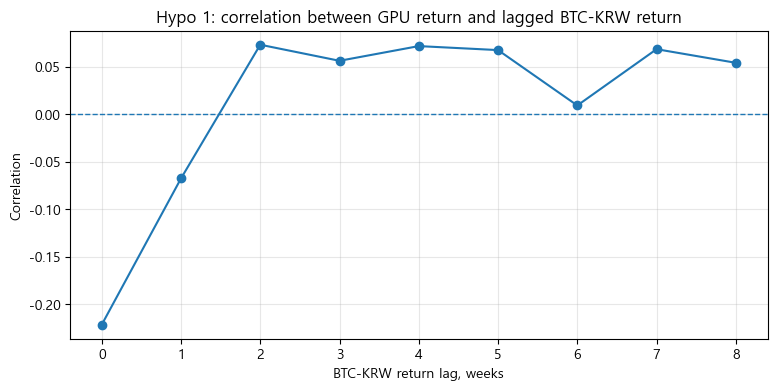

In [6]:
lag_corr_rows = []

for k in range(MAX_LAG + 1):
    col = f"btc_krw_ret_l{k}"
    temp = h1[["gpu_ret", col]].dropna()
    lag_corr_rows.append({
        "lag_week": k,
        "corr_gpu_btc": temp["gpu_ret"].corr(temp[col]),
        "n": len(temp),
    })

lag_corr = pd.DataFrame(lag_corr_rows)
max_corr_row = lag_corr.loc[lag_corr["corr_gpu_btc"].abs().idxmax()]

print("BTC lag별 GPU 수익률과의 상관계수")
display(lag_corr.round(4))
print(f"max abs correlation lag = {int(max_corr_row['lag_week'])} week, corr = {max_corr_row['corr_gpu_btc']:.4f}")

lag_corr.to_csv(H1_OUT / "lag_corr.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(lag_corr["lag_week"], lag_corr["corr_gpu_btc"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 1: correlation between GPU return and lagged BTC-KRW return")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2-0. CCF plot: 시차 상관의 유의 경계선 확인</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
lag별 상관계수 선 그래프만 보면 어느 값이 통계적으로 의미 있는 크기인지 직관적으로 판단하기 어렵다. 따라서 Cross-Correlation Function 형태로 lag별 상관을 다시 그리고, 근사적 95% confidence band를 함께 표시한다.<br><br>
<b>[해석 기준]</b><br>
막대가 confidence band 안에 있으면 해당 lag의 상관은 표본 노이즈일 가능성이 크다. 다만 이 그림 역시 단변량 EDA이므로 최종 판단은 통제변수를 포함한 distributed lag regression의 공동 검정으로 한다.
</div>

Approximate 95% confidence band: ±0.1990, n_eff=97


,lag_week,corr_gpu_btc,n,conf_band_95
0,0,-0.2216,105,0.199
1,1,-0.0676,104,0.199
2,2,0.0732,103,0.199
3,3,0.0563,102,0.199
4,4,0.0717,101,0.199
5,5,0.0675,100,0.199
6,6,0.0092,99,0.199
7,7,0.0685,98,0.199
8,8,0.0541,97,0.199


[saved plot] output_pic\hypo_1\CCF-style_lag_correlation_BTC-KRW_return_vs_GPU_return.png


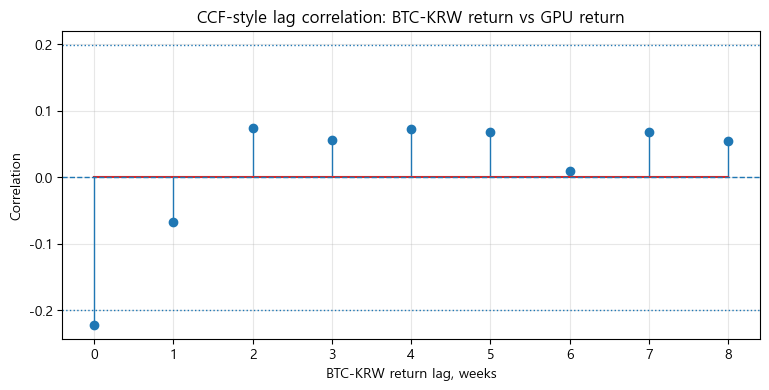

In [7]:
ccf = lag_corr.copy()
n_eff = int(ccf["n"].min())
ccf_band = 1.96 / np.sqrt(n_eff)
ccf["conf_band_95"] = ccf_band

print(f"Approximate 95% confidence band: ±{ccf_band:.4f}, n_eff={n_eff}")
display(ccf.round(4))
ccf.to_csv(H1_OUT / "ccf.csv", index=False)

plt.figure(figsize=(9, 4))
markerline, stemlines, baseline = plt.stem(ccf["lag_week"], ccf["corr_gpu_btc"])
plt.setp(stemlines, linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(ccf_band, linestyle=":", linewidth=1)
plt.axhline(-ccf_band, linestyle=":", linewidth=1)
plt.title("CCF-style lag correlation: BTC-KRW return vs GPU return")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Correlation")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2-1. Rolling correlation / beta EDA</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
전체 기간의 단일 상관계수는 기간별 regime 변화를 가릴 수 있다. 따라서 rolling correlation과 rolling beta로 BTC-GPU 관계가 특정 시기에만 강했는지 확인한다.<br><br>
<b>[이번 보완점]</b><br>
8주·12주 window는 시장 변화에 빠르게 반응하지만 표본 수가 작아 노이즈가 크게 튈 수 있다. 그래서 24주 window를 추가해 약 반년 단위의 중기 관계도 함께 확인한다.<br>
• 8주/12주: 단기 regime 변화 탐색용<br>
• 24주: 자유도 부족으로 인한 과도한 진동을 줄인 중기 trend 확인용<br><br>
<b>[해석 기준]</b><br>
rolling 지표는 확증 검정이 아니라 시각적 EDA이다. 특정 구간에서 값이 튀더라도 최종 결론은 distributed lag regression, joint test, Granger, cointegration 결과와 함께 판단한다.
</div>

Rolling correlation / beta summary


,metric,count,mean,std,min,max
0,corr_8w,98.0,-0.0405,0.4386,-0.8973,0.7424
1,beta_8w,98.0,-0.0166,0.0627,-0.3395,0.2048
2,corr_12w,94.0,-0.0774,0.3583,-0.6550,0.6457
3,beta_12w,94.0,-0.0180,0.0466,-0.1648,0.0742
4,corr_24w,82.0,-0.1255,0.1798,-0.3842,0.2700
5,beta_24w,82.0,-0.0230,0.0338,-0.1216,0.0202


[saved plot] output_pic\hypo_1\Rolling_BTC-GPU_return_correlation.png


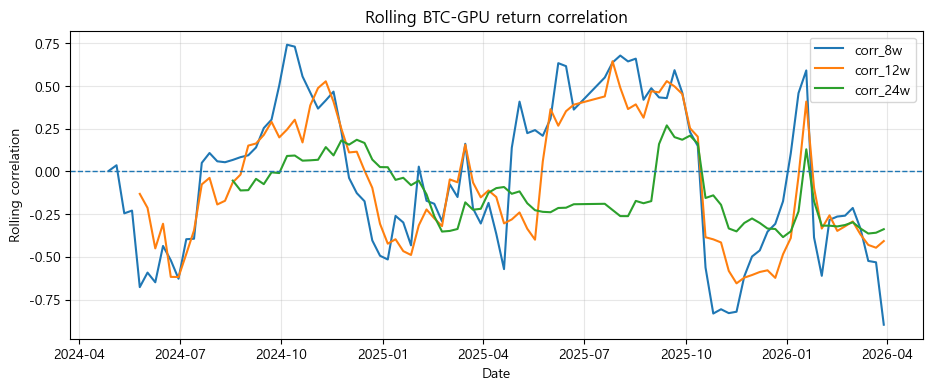

[saved plot] output_pic\hypo_1\Rolling_BTC_beta_of_GPU_return.png


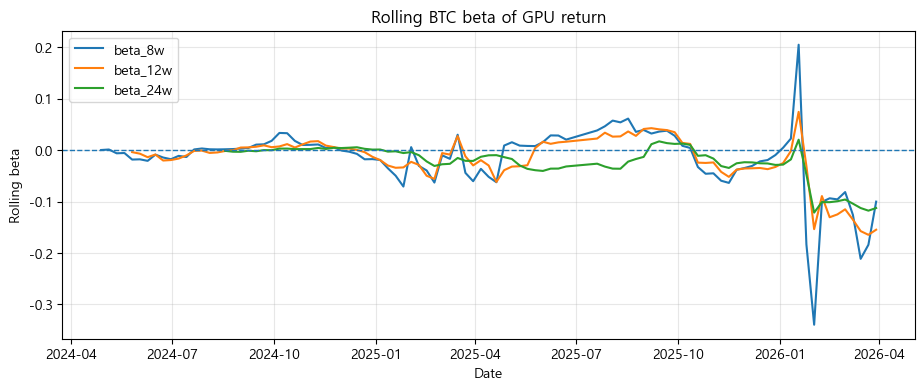

In [8]:
roll_base = h1[["gpu_ret", "btc_krw_ret"]].dropna().copy()
roll = pd.DataFrame(index=roll_base.index)
ROLL_WINDOWS = [8, 12, 24]

for w in ROLL_WINDOWS:
    roll[f"corr_{w}w"] = roll_base["gpu_ret"].rolling(w, min_periods=w).corr(roll_base["btc_krw_ret"])
    roll[f"beta_{w}w"] = (
        roll_base["gpu_ret"].rolling(w, min_periods=w).cov(roll_base["btc_krw_ret"])
        / roll_base["btc_krw_ret"].rolling(w, min_periods=w).var()
    )

roll_summary = (
    roll.agg(["count", "mean", "std", "min", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

print("Rolling correlation / beta summary")
display(roll_summary.round(4))
roll.to_csv(H1_OUT / "roll.csv")
roll_summary.to_csv(H1_OUT / "roll_sum.csv", index=False)

plt.figure(figsize=(11, 4))
for col in [f"corr_{w}w" for w in ROLL_WINDOWS]:
    plt.plot(roll.index, roll[col], label=col)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling BTC-GPU return correlation")
plt.xlabel("Date")
plt.ylabel("Rolling correlation")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(11, 4))
for col in [f"beta_{w}w" for w in ROLL_WINDOWS]:
    plt.plot(roll.index, roll[col], label=col)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling BTC beta of GPU return")
plt.xlabel("Date")
plt.ylabel("Rolling beta")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2-2. Regime EDA: 기간별·BTC 변동성별 관계 변화</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
전체 기간 평균 상관 하나만 보면 특정 시기의 구조적 변화가 묻힐 수 있다. 명확한 거시 이벤트 날짜를 임의로 지정하지 않고, 먼저 데이터 내부 기준으로 early/late 기간과 BTC 고변동/저변동 regime을 나눠 상관과 beta가 달라지는지 확인한다.<br><br>
<b>[해석 기준]</b><br>
regime별 결과는 구조적 변화 가능성을 보여주는 EDA이다. 사후적으로 나눈 구간이므로 가설 채택 근거로 직접 쓰기보다는, rolling plot과 함께 “관계가 안정적인가”를 점검하는 보조 근거로 사용한다.
</div>

In [9]:
reg = h1[["gpu_ret", "btc_krw_ret"]].dropna().copy()
reg = reg.sort_index()

mid_pos = len(reg) // 2
mid_date = reg.index[mid_pos]
reg["time_regime"] = np.where(reg.index < mid_date, "early", "late")

reg["btc_vol_12w"] = reg["btc_krw_ret"].rolling(12, min_periods=12).std()
vol_cut = reg["btc_vol_12w"].median()
reg["btc_vol_regime"] = np.where(reg["btc_vol_12w"] >= vol_cut, "high_btc_vol", "low_btc_vol")
reg.loc[reg["btc_vol_12w"].isna(), "btc_vol_regime"] = np.nan


def corr_beta_by_group(df, group_col):
    rows = []
    for label, sub in df.dropna(subset=[group_col]).groupby(group_col):
        sub = sub[["gpu_ret", "btc_krw_ret"]].dropna()
        if len(sub) < 8:
            continue
        beta = sub["gpu_ret"].cov(sub["btc_krw_ret"]) / sub["btc_krw_ret"].var()
        rows.append({
            "regime_type": group_col,
            "regime": label,
            "n": len(sub),
            "corr": sub["gpu_ret"].corr(sub["btc_krw_ret"]),
            "beta": beta,
        })
    return pd.DataFrame(rows)

regime_stats = pd.concat([
    corr_beta_by_group(reg, "time_regime"),
    corr_beta_by_group(reg, "btc_vol_regime"),
], ignore_index=True)

print("Regime-level BTC-GPU correlation and beta")
display(regime_stats.round(4))
reg.to_csv(H1_OUT / "regime.csv")
regime_stats.to_csv(H1_OUT / "regime_beta.csv", index=False)

Regime-level BTC-GPU correlation and beta


,regime_type,regime,n,corr,beta
0,time_regime,early,52,-0.0928,-0.0061
1,time_regime,late,53,-0.3388,-0.0945
2,btc_vol_regime,high_btc_vol,47,-0.2848,-0.0482
3,btc_vol_regime,low_btc_vol,47,-0.1783,-0.0457


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3. 편상관 보조분석: 통제변수를 제거한 BTC-GPU 관계</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
다변량 회귀의 BTC lag 계수는 이미 환율, NVDA, GPU 자기시차를 통제한 조건부 관계이다. 하지만 발표에서 “편상관관계와 같은 의미인가?”라는 질문이 나올 수 있으므로, 각 BTC lag에 대해 통제변수의 영향을 먼저 제거한 뒤 잔차끼리의 상관을 계산한다.<br><br>
<b>[해석 기준]</b><br>
partial correlation이 단순 lag correlation보다 크게 줄어들면, 기존 상관의 상당 부분이 환율, NVDA, 또는 GPU 자기시차에 의해 설명되었을 가능성이 있다. 반대로 통제 후에도 특정 lag에서 상관이 유지되면 BTC 고유의 조건부 관계가 남아있다는 보조 근거가 된다.<br><br>
<b>[주의]</b><br>
partial correlation은 보조 EDA이고, 최종 p-value 판단은 HAC 표준오차를 적용한 distributed lag regression과 BTC lag 공동 유의성 검정에서 한다.
</div>

Partial correlation by BTC lag after controlling FX, NVDA, and GPU lag 1


,lag_week,partial_corr_gpu_btc,n
0,0,0.0381,103
1,1,0.1560,103
2,2,0.1855,102
3,3,0.0043,101
4,4,0.0064,100
5,5,0.0235,99
6,6,-0.0504,98
7,7,0.1121,97
8,8,0.0427,96


[saved plot] output_pic\hypo_1\Partial_correlation_GPU_return_vs_lagged_BTC-KRW_return.png


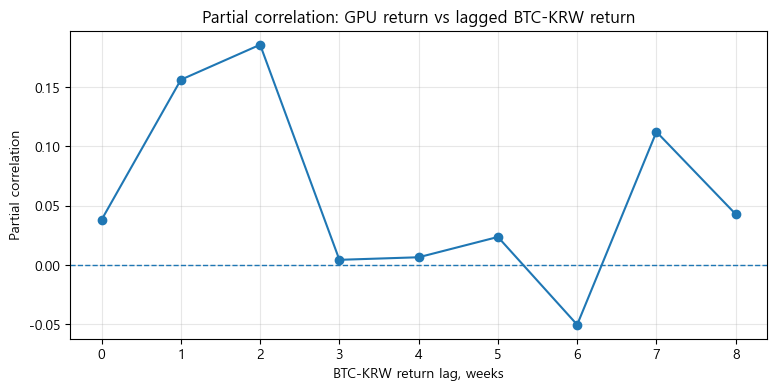

In [10]:
def residualize(y, X):
    X_const = sm.add_constant(X.astype(float))
    return sm.OLS(y.astype(float), X_const).fit().resid

partial_rows = []
control_cols = ["fx_ret", "nvda_ret", "gpu_ret_l1"]

for k in range(MAX_LAG + 1):
    btc_col = f"btc_krw_ret_l{k}"
    temp = h1[["gpu_ret", btc_col] + control_cols].dropna().copy()
    gpu_resid = residualize(temp["gpu_ret"], temp[control_cols])
    btc_resid = residualize(temp[btc_col], temp[control_cols])
    partial_rows.append({
        "lag_week": k,
        "partial_corr_gpu_btc": pd.Series(gpu_resid).corr(pd.Series(btc_resid)),
        "n": len(temp),
    })

partial_corr = pd.DataFrame(partial_rows)

print("Partial correlation by BTC lag after controlling FX, NVDA, and GPU lag 1")
display(partial_corr.round(4))
partial_corr.to_csv(H1_OUT / "partial_corr.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(partial_corr["lag_week"], partial_corr["partial_corr_gpu_btc"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Partial correlation: GPU return vs lagged BTC-KRW return")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Partial correlation")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4. Distributed Lag Regression: Hypo 1 메인 검정</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
Hypothesis 1은 단순히 BTC와 GPU가 같은 주에 같이 움직였는지가 아니라, BTC 변동이 <b>여러 주의 시차를 두고</b> GPU 가격에 반영되는지를 검정한다. 그래서 BTC 수익률의 현재값과 1~8주 lag를 한 회귀식에 함께 넣는 <b>distributed lag regression</b>을 사용한다.<br><br>
<b>[통계적 의미]</b><br>
각 BTC lag 계수는 환율, NVDA, GPU 자기시차를 통제한 뒤 해당 시차의 BTC 수익률이 GPU 수익률과 갖는 조건부 관계이다. 이는 편상관관계의 회귀분석 버전이라고 이해할 수 있다.<br><br>
<b>[왜 HAC 표준오차를 쓰는가]</b><br>
주간 시계열 회귀에서는 잔차의 자기상관과 이분산이 생길 수 있다. 일반 OLS 표준오차를 그대로 쓰면 p-value가 과도하게 작아질 수 있으므로, Newey-West 방식의 <b>HAC 표준오차</b>로 보정한다.<br><br>
<b>[실행 후 해석]</b><br>
• 특정 lag의 계수가 유의하면 해당 시차에서 BTC 변화가 GPU 변화와 조건부로 연결되어 있다는 뜻이다.<br>
• 여러 lag가 동시에 약하게 작용할 수 있으므로, 단일 계수보다 다음 단계의 <b>BTC lag 공동 유의성 검정</b>이 더 중요하다.
</div>

                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     7.745
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.91e-09
Time:                        14:09:25   Log-Likelihood:                 349.84
No. Observations:                  96   AIC:                            -673.7
Df Residuals:                      83   BIC:                            -640.3
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0001      0.001      0.

,term,coef,se_HAC,t_HAC,p_value_HAC,lag_week
1,btc_krw_ret_l0,-0.00322,0.01498,-0.21507,0.82971,0
2,btc_krw_ret_l1,0.01804,0.01334,1.35218,0.17632,1
3,btc_krw_ret_l2,0.03121,0.02110,1.47959,0.13898,2
4,btc_krw_ret_l3,-0.01855,0.01030,-1.80173,0.07159,3
5,btc_krw_ret_l4,0.00531,0.01386,0.38303,0.70170,4
6,btc_krw_ret_l5,0.00306,0.01020,0.29973,0.76438,5
7,btc_krw_ret_l6,-0.02101,0.00883,-2.38088,0.01727,6
8,btc_krw_ret_l7,0.02586,0.01475,1.75281,0.07964,7
9,btc_krw_ret_l8,0.00624,0.01509,0.41376,0.67905,8


[saved plot] output_pic\hypo_1\Hypo_1_distributed_lag_coefficients_of_BTC-KRW_returns.png


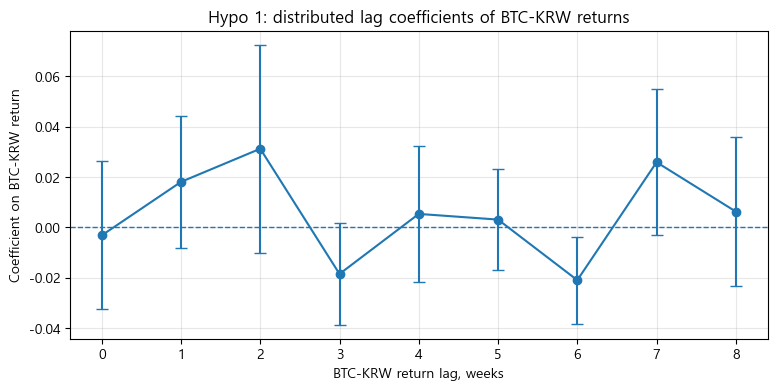

In [11]:
h1_reg = h1[reg_cols].dropna().copy()

formula = (
    "gpu_ret ~ "
    + " + ".join(btc_lag_cols)
    + " + fx_ret + nvda_ret + gpu_ret_l1"
)

h1_model = smf.ols(formula, data=h1_reg).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": HAC_LAG},
)

print(h1_model.summary())

coef_table = pd.DataFrame({
    "term": h1_model.params.index,
    "coef": h1_model.params.values,
    "se_HAC": h1_model.bse.values,
    "t_HAC": h1_model.tvalues.values,
    "p_value_HAC": h1_model.pvalues.values,
})

btc_coef = coef_table[coef_table["term"].isin(btc_lag_cols)].copy()
btc_coef["lag_week"] = btc_coef["term"].str.extract(r"l(\d+)").astype(int)
btc_coef = btc_coef.sort_values("lag_week")

print("BTC lag coefficient table")
display(btc_coef.round(5))

coef_table.to_csv(H1_OUT / "dl_coef.csv", index=False)
btc_coef.to_csv(H1_OUT / "btc_lag_coef.csv", index=False)

plt.figure(figsize=(9, 4))
plt.errorbar(
    btc_coef["lag_week"],
    btc_coef["coef"],
    yerr=1.96 * btc_coef["se_HAC"],
    marker="o",
    capsize=4,
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 1: distributed lag coefficients of BTC-KRW returns")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Coefficient on BTC-KRW return")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4-1. 잔차 변동성 군집 점검</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
금융 시계열에서는 평균 관계가 약해도 변동성 자체가 특정 시기에 몰리는 volatility clustering이 나타날 수 있다. BTC 급등락 구간에서 GPU 가격의 예측오차 변동성도 커지는지 확인하기 위해, distributed lag regression 잔차의 제곱을 시계열로 진단한다.<br><br>
<b>[해석 기준]</b><br>
잔차 제곱의 Ljung-Box p-value가 작으면 변동성 군집이 남아 있을 수 있다. 이는 평균 수익률 회귀의 주효과가 약하더라도, 하드웨어 가격 변동성 모델링이 별도 과제가 될 수 있음을 의미한다.
</div>

Residual volatility correlation with BTC volatility


,corr_resid_sq_btc_abs,corr_resid_sq_btc_sq,mean_resid_sq,max_resid_sq
0,0.33943,0.32395,0.00004,0.00085


Ljung-Box test on squared residuals


,lag,lb_stat,lb_pvalue
0,4,66.59426,0.0
1,8,67.06786,0.0


[saved plot] output_pic\hypo_1\Squared_residuals_from_H1_distributed_lag_regression.png


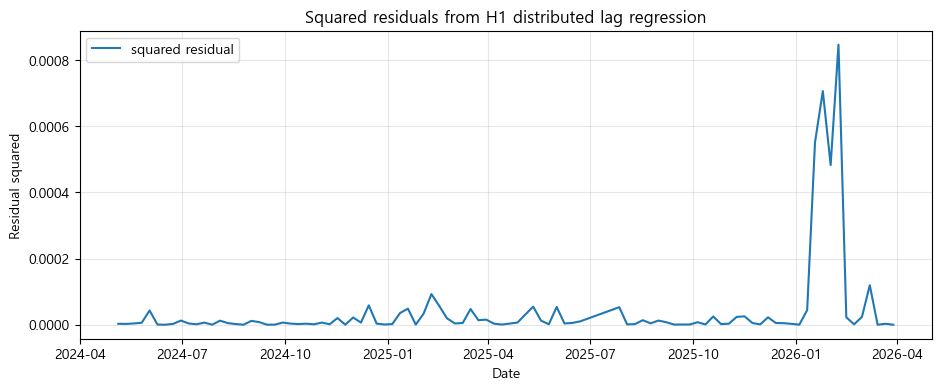

[saved plot] output_pic\hypo_1\BTC_volatility_proxy_and_GPU_regression_residual_volatility.png


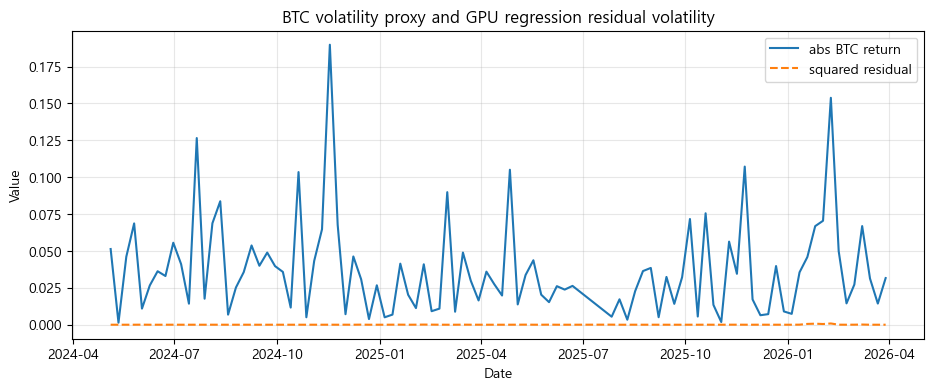

In [12]:
resid_vol = h1_reg[["gpu_ret", "btc_krw_ret_l0", "fx_ret", "nvda_ret"]].copy()
resid_vol = resid_vol.rename(columns={"btc_krw_ret_l0": "btc_krw_ret"})

resid_vol["resid"] = h1_model.resid
resid_vol["resid_sq"] = resid_vol["resid"] ** 2
resid_vol["btc_abs"] = resid_vol["btc_krw_ret"].abs()
resid_vol["btc_sq"] = resid_vol["btc_krw_ret"] ** 2

vol_corr = pd.DataFrame([{
    "corr_resid_sq_btc_abs": resid_vol["resid_sq"].corr(resid_vol["btc_abs"]),
    "corr_resid_sq_btc_sq": resid_vol["resid_sq"].corr(resid_vol["btc_sq"]),
    "mean_resid_sq": resid_vol["resid_sq"].mean(),
    "max_resid_sq": resid_vol["resid_sq"].max(),
}])

lb_sq = acorr_ljungbox(
    resid_vol["resid_sq"].dropna(),
    lags=[4, 8],
    return_df=True,
).reset_index().rename(columns={"index": "lag"})

print("Residual volatility correlation with BTC volatility")
display(vol_corr.round(5))
print("Ljung-Box test on squared residuals")
display(lb_sq.round(5))

resid_vol.to_csv(H1_OUT / "resid_vol.csv")
vol_corr.to_csv(H1_OUT / "resid_vol_corr.csv", index=False)
lb_sq.to_csv(H1_OUT / "resid_vol_lb.csv", index=False)

plt.figure(figsize=(11, 4))
plt.plot(resid_vol.index, resid_vol["resid_sq"], label="squared residual")
plt.title("Squared residuals from H1 distributed lag regression")
plt.xlabel("Date")
plt.ylabel("Residual squared")
plt.grid(True, alpha=0.3)
plt.legend()
save_plot(); plt.show()

plt.figure(figsize=(11, 4))
plt.plot(resid_vol.index, resid_vol["btc_abs"], label="abs BTC return")
plt.plot(resid_vol.index, resid_vol["resid_sq"], label="squared residual", linestyle="--")
plt.title("BTC volatility proxy and GPU regression residual volatility")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4-2. Fat-tail 잔차 진단과 robust regression 보조확인</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
OLS summary에서 잔차 첨도가 높고 Jarque-Bera 검정이 유의하면, 평균적으로는 모델이 맞더라도 일부 극단 주차가 계수와 p-value에 영향을 줄 수 있다. 기존 HAC 표준오차는 자기상관·이분산 보정에는 유용하지만, fat-tail 자체를 없애지는 않는다.<br><br>
<b>[처리 방식]</b><br>
잔차의 skewness, kurtosis, Jarque-Bera p-value를 저장하고, 극단값에 덜 민감한 Huber robust regression을 보조적으로 수행한다. 메인 결론은 HAC OLS의 공동 검정 기준으로 유지하되, robust regression에서 계수 방향이 크게 달라지는지 확인한다.
</div>

Residual distribution diagnostic


,n,mean,std,skew,kurtosis,jarque_bera_stat,jarque_bera_p,omni_stat,omni_p
0,96,0.0,0.00636,0.66646,11.75021,313.37122,0.0,34.00854,0.0


Huber robust regression coefficients


,term,coef_huber,se_huber,t_huber,p_value_huber
0,const,-0.00020,0.00033,-0.58600,0.55788
1,btc_krw_ret_l0,-0.00817,0.00777,-1.05135,0.29310
2,btc_krw_ret_l1,0.01039,0.00771,1.34849,0.17750
3,btc_krw_ret_l2,0.00985,0.00771,1.27835,0.20112
4,btc_krw_ret_l3,-0.00850,0.00760,-1.11778,0.26366
5,btc_krw_ret_l4,0.00840,0.00778,1.07979,0.28024
6,btc_krw_ret_l5,0.00779,0.00728,1.06982,0.28470
7,btc_krw_ret_l6,-0.01539,0.00719,-2.14059,0.03231
8,btc_krw_ret_l7,0.01128,0.00726,1.55354,0.12029
9,btc_krw_ret_l8,0.01403,0.00741,1.89206,0.05848


[saved plot] output_pic\hypo_1\Residual_distribution_from_H1_distributed_lag_regression.png


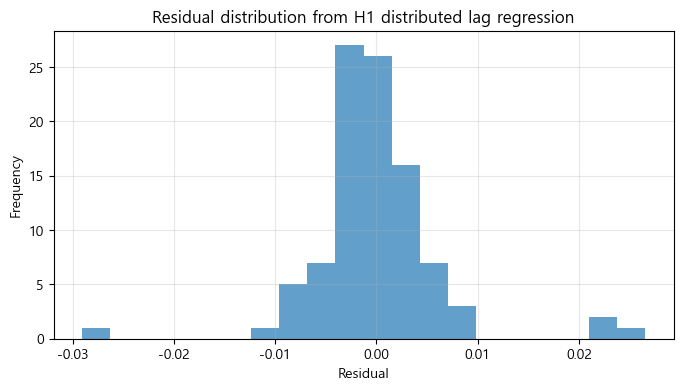

In [13]:
from statsmodels.stats.stattools import jarque_bera, omni_normtest

resid = pd.Series(h1_model.resid, index=h1_reg.index, name="resid")
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
omni_stat, omni_p = omni_normtest(resid)

resid_dist = pd.DataFrame([{
    "n": len(resid),
    "mean": resid.mean(),
    "std": resid.std(),
    "skew": skew,
    "kurtosis": kurt,
    "jarque_bera_stat": jb_stat,
    "jarque_bera_p": jb_p,
    "omni_stat": omni_stat,
    "omni_p": omni_p,
}])

print("Residual distribution diagnostic")
display(resid_dist.round(5))
resid_dist.to_csv(H1_OUT / "resid_dist.csv", index=False)

rlm_X = sm.add_constant(h1_reg[btc_lag_cols + ["fx_ret", "nvda_ret", "gpu_ret_l1"]].astype(float), has_constant="add")
rlm_y = h1_reg["gpu_ret"].astype(float)
rlm_model = sm.RLM(rlm_y, rlm_X, M=sm.robust.norms.HuberT()).fit()

rlm_coef = pd.DataFrame({
    "term": rlm_model.params.index,
    "coef_huber": rlm_model.params.values,
    "se_huber": rlm_model.bse.values,
    "t_huber": rlm_model.tvalues.values,
    "p_value_huber": rlm_model.pvalues.values,
})

print("Huber robust regression coefficients")
display(rlm_coef.round(5))
rlm_coef.to_csv(H1_OUT / "huber_coef.csv", index=False)

plt.figure(figsize=(8, 4))
plt.hist(resid, bins=20, alpha=0.7)
plt.title("Residual distribution from H1 distributed lag regression")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>4-3. Residual Plot / Q-Q Plot: 특정 국면 누락 여부 확인</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
Jarque-Bera와 kurtosis 수치만으로는 잔차가 어느 시점에 튀었는지, 정규성에서 어떻게 벗어나는지 직관적으로 보기 어렵다. 따라서 잔차 시계열 그래프와 Q-Q plot을 추가해 특정 시장 국면에서 모형이 놓친 충격이 있는지 확인한다.<br><br>
<b>[해석]</b><br>
잔차가 특정 주간에 크게 튀면 BTC/FX/NVDA 이외의 신제품 출시, 재고, 기술주 이벤트, 유통망 충격 등이 남아 있을 수 있다. Q-Q plot의 양끝이 크게 벗어나면 fat-tail이 존재한다는 뜻이므로, HAC 표준오차와 Huber robust regression을 함께 제시하는 이유가 강화된다.<br><br>
</div>

Top residual spikes from H1 main model


,date,resid,fitted,std_resid,abs_std_resid
88,2026-02-08,-0.02909,0.04181,-4.57371,4.57371
86,2026-01-25,0.02657,0.02261,4.17799,4.17799
85,2026-01-18,0.02347,0.00396,3.68993,3.68993
87,2026-02-01,0.02196,0.04084,3.45357,3.45357
92,2026-03-08,-0.01093,0.00190,-1.71819,1.71819
40,2025-02-09,0.00962,-0.00134,1.51295,1.51295
32,2024-12-15,0.00765,-0.00109,1.20317,1.20317
41,2025-02-16,0.00754,0.00591,1.18497,1.18497
53,2025-05-11,-0.00739,0.00187,-1.16238,1.16238
56,2025-06-01,-0.00732,-0.00039,-1.15161,1.15161


[saved plot] output_pic\hypo_1\H1_residual_plot_distributed_lag_model.png


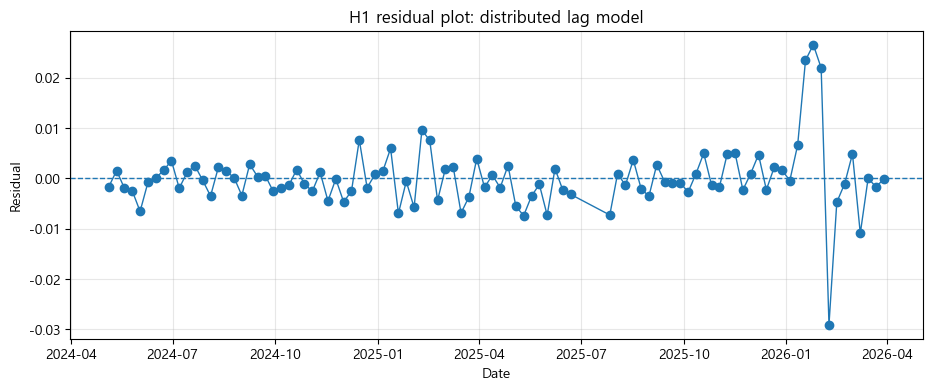

[saved plot] output_pic\hypo_1\H1_residual_Q-Q_plot.png


<Figure size 500x500 with 0 Axes>

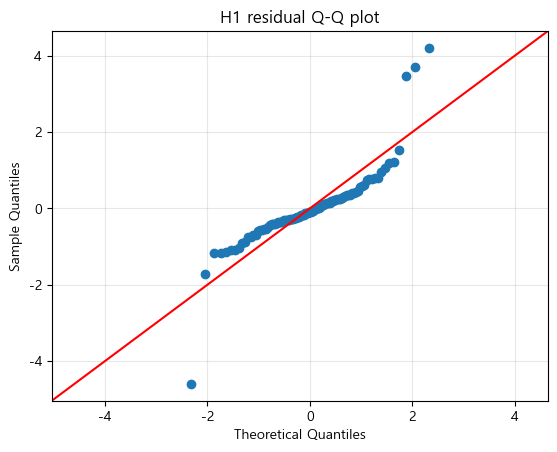

In [14]:
resid_vis = pd.DataFrame({
    "date": h1_reg.index,
    "resid": h1_model.resid,
    "fitted": h1_model.fittedvalues,
}).set_index("date")
resid_vis["std_resid"] = resid_vis["resid"] / resid_vis["resid"].std(ddof=1)
resid_vis["abs_std_resid"] = resid_vis["std_resid"].abs()

resid_spikes = (
    resid_vis.reset_index()
    .sort_values("abs_std_resid", ascending=False)
    .head(10)
)

print("Top residual spikes from H1 main model")
display(resid_spikes.round(5))

resid_vis.to_csv(H1_OUT / "resid_series.csv")
resid_spikes.to_csv(H1_OUT / "resid_spike.csv", index=False)

plt.figure(figsize=(11, 4))
plt.plot(resid_vis.index, resid_vis["resid"], marker="o", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("H1 residual plot: distributed lag model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(5, 5))
sm.qqplot(resid_vis["resid"].dropna(), line="45", fit=True)
plt.title("H1 residual Q-Q plot")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5. BTC lag 공동 유의성 검정 + VIF 점검</mark></b></span><br><br>
<b>[왜 공동 유의성 검정을 하는가]</b><br>
BTC 효과는 한 주 lag에만 집중되지 않고 여러 주에 분산될 수 있다. 따라서 개별 p-value만 보면 전체 BTC 시차 효과를 놓칠 수 있다. 그래서 <b>H0: btc_lag_0 = ... = btc_lag_8 = 0</b>이라는 공동 귀무가설을 검정한다.<br><br>
<b>[왜 VIF를 확인하는가]</b><br>
BTC, NVDA, 환율은 특정 시장 국면에서 함께 움직일 수 있다. 다중공선성이 크면 계수 자체가 틀리는 것은 아니지만 표준오차가 커져 유의성이 약해질 수 있다. 그래서 <b>core VIF</b>로 핵심 통제변수 간 중복성을 점검한다.<br><br>
<b>[실행 후 해석]</b><br>
• 공동 유의성 p-value가 작으면 BTC lag 전체가 GPU 수익률을 설명하는 데 통계적으로 유의하다고 해석한다.<br>
• VIF가 높으면 “BTC 효과가 없다”가 아니라 “BTC와 통제변수가 동시에 움직여 계수 추정의 불확실성이 커졌다”고 해석한다.
</div>

In [15]:
joint_hypothesis = ", ".join([f"{col} = 0" for col in btc_lag_cols])
joint_test = h1_model.f_test(joint_hypothesis)

joint_result = pd.DataFrame([{
    "hypothesis": f"btc_krw_ret_l0 ~ btc_krw_ret_l{MAX_LAG} jointly zero",
    "F_stat": float(np.asarray(joint_test.fvalue)),
    "p_value": float(np.asarray(joint_test.pvalue)),
    "df_num": float(joint_test.df_num),
    "df_denom": float(joint_test.df_denom),
}])

print("BTC lag 공동 유의성 검정")
display(joint_result)
joint_result.to_csv(H1_OUT / "joint.csv", index=False)


def make_vif_table(df, cols):
    X = sm.add_constant(df[cols].astype(float))
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i),
        })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_core = make_vif_table(h1_reg, ["btc_krw_ret_l0", "fx_ret", "nvda_ret", "gpu_ret_l1"])

vif_full = make_vif_table(h1_reg, btc_lag_cols + ["fx_ret", "nvda_ret", "gpu_ret_l1"])

print("Core VIF: BTC contemporaneous return, FX, NVDA, GPU lag")
display(vif_core.round(3))

print("Full model VIF: includes all BTC lags")
display(vif_full.round(3))

vif_core.to_csv(H1_OUT / "vif_core.csv", index=False)
vif_full.to_csv(H1_OUT / "vif_full.csv", index=False)

BTC lag 공동 유의성 검정


,hypothesis,F_stat,p_value,df_num,df_denom
0,btc_krw_ret_l0 ~ btc_krw_ret_l8 jointly zero,1.701005,0.101684,9.0,83.0


Core VIF: BTC contemporaneous return, FX, NVDA, GPU lag


,variable,VIF
0,btc_krw_ret_l0,1.237
3,gpu_ret_l1,1.167
2,nvda_ret,1.096
1,fx_ret,1.038


Full model VIF: includes all BTC lags


,variable,VIF
2,btc_krw_ret_l2,1.433
4,btc_krw_ret_l4,1.432
0,btc_krw_ret_l0,1.411
1,btc_krw_ret_l1,1.389
3,btc_krw_ret_l3,1.388
5,btc_krw_ret_l5,1.281
7,btc_krw_ret_l7,1.277
6,btc_krw_ret_l6,1.259
11,gpu_ret_l1,1.241
10,nvda_ret,1.241


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>5-0. NASDAQ/SOX 확장 통제 robustness</mark></b></span><br><br>
<b>[왜 본모형이 아니라 robustness인가]</b><br>
NASDAQ과 SOX는 기술주·반도체 시장 전반의 움직임을 대변하므로 BTC 효과가 단순한 위험자산 장세와 섞였는지 확인하는 데 도움이 된다. 그러나 NVDA, SOX, NASDAQ은 서로 비슷한 시장 요인을 공유해 다중공선성 또는 과통제 가능성이 있다. 따라서 본모형은 FX+NVDA 통제 모형으로 유지하고, 이 셀은 확장 통제 결과가 결론을 뒤집는지 확인하는 보조 분석으로 사용한다.<br><br>
</div>

In [16]:
ext_ctrls = ["fx_ret", "nvda_ret", "nasdaq_ret", "sox_ret", "gpu_ret_l1"]
ext_cols = ["gpu_ret"] + btc_lag_cols + ext_ctrls
h1_ext_reg = h1[ext_cols].dropna().copy()

ext_formula = (
    "gpu_ret ~ "
    + " + ".join(btc_lag_cols)
    + " + fx_ret + nvda_ret + nasdaq_ret + sox_ret + gpu_ret_l1"
)

h1_ext_model = smf.ols(ext_formula, data=h1_ext_reg).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": HAC_LAG},
)

ext_joint = h1_ext_model.f_test(", ".join([f"{col} = 0" for col in btc_lag_cols]))
ext_joint_result = pd.DataFrame([{
    "model": "extended_market_controls",
    "controls": "FX, NVDA, NASDAQ, SOX, GPU lag 1",
    "F_stat": float(np.asarray(ext_joint.fvalue).ravel()[0]),
    "p_value": float(np.asarray(ext_joint.pvalue).ravel()[0]),
    "df_num": float(ext_joint.df_num),
    "df_denom": float(ext_joint.df_denom),
    "n": len(h1_ext_reg),
}])

ext_coef = pd.DataFrame({
    "term": h1_ext_model.params.index,
    "coef": h1_ext_model.params.values,
    "se_HAC": h1_ext_model.bse.values,
    "t_HAC": h1_ext_model.tvalues.values,
    "p_value_HAC": h1_ext_model.pvalues.values,
})

ext_vif = make_vif_table(h1_ext_reg, ["btc_krw_ret_l0", "fx_ret", "nvda_ret", "nasdaq_ret", "sox_ret", "gpu_ret_l1"])

print(h1_ext_model.summary())
print("Extended-control BTC lag joint test")
display(ext_joint_result.round(5))
print("Extended-control core VIF")
display(ext_vif.round(3))

ext_coef.to_csv(H1_OUT / "ext_coef.csv", index=False)
ext_joint_result.to_csv(H1_OUT / "ext_joint.csv", index=False)
ext_vif.to_csv(H1_OUT / "ext_vif.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     5.265
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.75e-07
Time:                        14:09:51   Log-Likelihood:                 352.71
No. Observations:                  96   AIC:                            -675.4
Df Residuals:                      81   BIC:                            -637.0
Df Model:                          14                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       8.595e-05      0.000      0.

,model,controls,F_stat,p_value,df_num,df_denom,n
0,extended_market_controls,"FX, NVDA, NASDAQ, SOX, GPU lag 1",2.23952,0.02737,9.0,81.0,96


Extended-control core VIF


,variable,VIF
4,sox_ret,5.259
3,nasdaq_ret,4.666
2,nvda_ret,2.911
0,btc_krw_ret_l0,1.459
5,gpu_ret_l1,1.178
1,fx_ret,1.050


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-1. GPU 자기시차 의존성 점검</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
메인 회귀의 설명력이 높더라도 그 대부분이 BTC가 아니라 GPU 가격 자체의 관성에서 나올 수 있다. 특히 `gpu_ret_l1`의 t-value가 크면, BTC 효과를 과대해석하지 않도록 R-squared 증가분을 분리해서 확인해야 한다.<br><br>
<b>[해석 기준]</b><br>
controls only, controls + GPU lag, controls + BTC lags, full model을 같은 표본에서 비교한다. BTC lag를 추가했을 때의 설명력 증가가 작고 GPU lag 추가분이 크면, 모형의 설명력은 BTC보다 자기상관에 더 의존한다고 해석한다.
</div>

In [17]:
def fit_hac_formula(formula):
    return smf.ols(formula, data=h1_reg).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAG})

btc_rhs = " + ".join(btc_lag_cols)
mod_controls = fit_hac_formula("gpu_ret ~ fx_ret + nvda_ret")
mod_controls_ar = fit_hac_formula("gpu_ret ~ fx_ret + nvda_ret + gpu_ret_l1")
mod_controls_btc = fit_hac_formula("gpu_ret ~ " + btc_rhs + " + fx_ret + nvda_ret")
mod_full = h1_model

model_comp = pd.DataFrame([
    {"model": "controls_only", "r2": mod_controls.rsquared, "adj_r2": mod_controls.rsquared_adj, "aic": mod_controls.aic, "bic": mod_controls.bic},
    {"model": "controls_plus_gpu_l1", "r2": mod_controls_ar.rsquared, "adj_r2": mod_controls_ar.rsquared_adj, "aic": mod_controls_ar.aic, "bic": mod_controls_ar.bic},
    {"model": "controls_plus_btc_lags", "r2": mod_controls_btc.rsquared, "adj_r2": mod_controls_btc.rsquared_adj, "aic": mod_controls_btc.aic, "bic": mod_controls_btc.bic},
    {"model": "full_btc_lags_controls_gpu_l1", "r2": mod_full.rsquared, "adj_r2": mod_full.rsquared_adj, "aic": mod_full.aic, "bic": mod_full.bic},
])

increment_rows = pd.DataFrame([
    {
        "comparison": "add_gpu_l1_after_controls",
        "delta_r2": mod_controls_ar.rsquared - mod_controls.rsquared,
        "interpretation": "incremental explanatory power of GPU return persistence",
    },
    {
        "comparison": "add_btc_lags_after_controls",
        "delta_r2": mod_controls_btc.rsquared - mod_controls.rsquared,
        "interpretation": "incremental explanatory power of BTC lag structure before GPU lag",
    },
    {
        "comparison": "add_btc_lags_after_controls_and_gpu_l1",
        "delta_r2": mod_full.rsquared - mod_controls_ar.rsquared,
        "interpretation": "BTC incremental explanatory power in the main specification",
    },
    {
        "comparison": "add_gpu_l1_after_controls_and_btc_lags",
        "delta_r2": mod_full.rsquared - mod_controls_btc.rsquared,
        "interpretation": "GPU persistence contribution after BTC lags",
    },
])

print("Nested model comparison")
display(model_comp.round(5))
print("Incremental R-squared decomposition")
display(increment_rows.round(5))
model_comp.to_csv(H1_OUT / "nested.csv", index=False)
increment_rows.to_csv(H1_OUT / "inc_r2.csv", index=False)

Nested model comparison


,model,r2,adj_r2,aic,bic
0,controls_only,0.00910,-0.01221,-615.21095,-607.51791
1,controls_plus_gpu_l1,0.51380,0.49795,-681.56317,-671.30578
2,controls_plus_btc_lags,0.09897,-0.01902,-606.33818,-575.56601
3,full_btc_lags_controls_gpu_l1,0.56239,0.49912,-673.67055,-640.33402


Incremental R-squared decomposition


,comparison,delta_r2,interpretation
0,add_gpu_l1_after_controls,0.50470,incremental explanatory power of GPU return pe...
1,add_btc_lags_after_controls,0.08987,incremental explanatory power of BTC lag struc...
2,add_btc_lags_after_controls_and_gpu_l1,0.04859,BTC incremental explanatory power in the main ...
3,add_gpu_l1_after_controls_and_btc_lags,0.46342,GPU persistence contribution after BTC lags


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-1. No-trim return robustness</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
기본 ret_w는 하드 오류 필터 이후 표본이 충분한 주에 5% 절사평균을 적용한다. 이 처리가 실제 crypto shock까지 약하게 만들었는지 확인하기 위해, EDA_process에서 저장한 <b>ret_all_notrim_w</b>를 사용해 같은 distributed lag regression을 다시 수행한다.<br><br>
<b>[해석 기준]</b><br>
no-trim에서도 BTC lag 공동 유의성 결론이 유지되면, Hypo 1 결론이 절사평균 처리에 의해 만들어진 것이 아니라는 강건성 근거로 사용한다.
</div>

In [18]:
ret_all_nt_w = (
    pd.read_csv(OUT / "ret_all_notrim_w.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)

h1_nt = (
    ret_all_nt_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_ret"})
    .join(mkt_w[MKT_RET_COLS], how="inner")
    .sort_index()
)

h1_nt["gpu_ret_l1"] = h1_nt["gpu_ret"].shift(1)
for k in range(MAX_LAG + 1):
    h1_nt[f"btc_krw_ret_l{k}"] = h1_nt["btc_krw_ret"].shift(k)

h1_nt_reg = h1_nt[reg_cols].dropna().copy()

h1_nt_model = smf.ols(formula, data=h1_nt_reg).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": HAC_LAG},
)

nt_joint_test = h1_nt_model.f_test(joint_hypothesis)
nt_joint = pd.DataFrame([{
    "block": "no_trim",
    "hypothesis": f"btc_krw_ret_l0 ~ btc_krw_ret_l{MAX_LAG} jointly zero",
    "F_stat": float(np.asarray(nt_joint_test.fvalue)),
    "p_value": float(np.asarray(nt_joint_test.pvalue)),
    "df_num": float(nt_joint_test.df_num),
    "df_denom": float(nt_joint_test.df_denom),
    "n": len(h1_nt_reg),
}])

nt_coef = pd.DataFrame({
    "term": h1_nt_model.params.index,
    "coef": h1_nt_model.params.values,
    "se_HAC": h1_nt_model.bse.values,
    "t_HAC": h1_nt_model.tvalues.values,
    "p_value_HAC": h1_nt_model.pvalues.values,
})

main_vs_notrim = pd.DataFrame([
    {
        "model": "main_trimmed",
        "n": len(h1_reg),
        "joint_p_value": float(joint_result.loc[0, "p_value"]),
    },
    {
        "model": "no_quantile_trim",
        "n": len(h1_nt_reg),
        "joint_p_value": float(nt_joint.loc[0, "p_value"]),
    },
])

print("H1 no-trim robustness joint test")
display(nt_joint.round(5))
display(main_vs_notrim.round(5))

nt_joint.to_csv(H1_OUT / "nt_joint.csv", index=False)
nt_coef.to_csv(H1_OUT / "nt_coef.csv", index=False)
main_vs_notrim.to_csv(H1_OUT / "nt_compare.csv", index=False)

H1 no-trim robustness joint test


,block,hypothesis,F_stat,p_value,df_num,df_denom,n
0,no_trim,btc_krw_ret_l0 ~ btc_krw_ret_l8 jointly zero,1.97149,0.05295,9.0,83.0,96


,model,n,joint_p_value
0,main_trimmed,96,0.10168
1,no_quantile_trim,96,0.05295


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>6. VAR 기반 다변량 Granger causality 보조 검정</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
단순 Granger test는 GPU와 BTC 두 변수만 넣는 이변량 검정이라, 환율과 NVDA를 통제하지 못한다. 메인 회귀에서 통제변수를 넣어놓고 보조 검정에서는 빼면 논리가 약해진다. 따라서 <b>GPU, BTC, FX, NVDA</b>를 함께 넣는 VAR 기반 Granger 검정을 사용한다.<br><br>
<b>[해석 제한]</b><br>
Granger causality는 경제적 인과관계 증명이 아니다. 정확한 표현은 “BTC 수익률이 GPU 수익률의 <b>예측적 선행지표</b>인지 확인했다”이다.<br><br>
<b>[실행 후 해석]</b><br>
p-value가 작으면 환율과 NVDA를 포함한 다변량 시계열 구조 안에서도 BTC 과거값이 GPU 수익률 예측에 추가 정보를 제공한다고 해석한다.
</div>

In [19]:
var_data = h1[["gpu_ret", "btc_krw_ret", "fx_ret", "nvda_ret"]].dropna().copy()

var_fit = VAR(var_data).fit(maxlags=MAX_LAG, ic="aic")
if var_fit.k_ar == 0:
    var_fit = VAR(var_data).fit(maxlags=1)

btc_to_gpu = var_fit.test_causality(
    caused="gpu_ret",
    causing=["btc_krw_ret"],
    kind="f",
)

var_result = pd.DataFrame([{
    "selected_lag": int(var_fit.k_ar),
    "test": "VAR Granger causality: BTC-KRW return -> GPU return | FX, NVDA included",
    "statistic": float(btc_to_gpu.test_statistic),
    "p_value": float(btc_to_gpu.pvalue),
    "df": str(btc_to_gpu.df),
    "interpretation_limit": "predictive precedence only; not structural/economic causality",
}])

print("VAR-based multivariate Granger causality test")
display(var_result)
var_result.to_csv(H1_OUT / "var_granger.csv", index=False)

VAR-based multivariate Granger causality test


,selected_lag,test,statistic,p_value,df,interpretation_limit
0,1,VAR Granger causality: BTC-KRW return -> GPU r...,2.545232,0.111425,"(1, 396)",predictive precedence only; not structural/eco...


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>7. 장기 관계 분석: ADF + Engle-Granger Cointegration</mark></b></span><br><br>
<b>[왜 이 기법을 쓰는가]</b><br>
단기 분석은 수익률을 사용하지만, 장기 관계는 가격지수 level에서 확인해야 한다. 다만 level 시계열은 비정상일 수 있으므로 먼저 ADF 검정으로 단위근 여부를 확인하고, 두 series가 I(1)에 가까울 때 Engle-Granger 공적분 검정을 수행한다.<br><br>
<b>[통계적 의미]</b><br>
공적분이 있다는 것은 GPU 가격지수와 BTC 가격이 각각 비정상이어도 둘의 특정 선형결합은 안정적일 수 있다는 뜻이다. 즉 단기적으로는 벗어나도 장기적으로 같이 움직이는 균형관계가 있을 수 있다.<br><br>
<b>[실행 후 해석]</b><br>
• level ADF에서 비정상, diff ADF에서 정상에 가까우면 수익률 기반 단기 분석이 적절하다는 근거가 된다.<br>
• Engle-Granger p-value가 작으면 장기 균형관계 가능성이 있다.<br>
• 공적분이 약하면 장기 균형 주장은 하지 않고 단기 lag 관계 중심으로 결론을 내린다.
</div>

In [20]:
level_h1 = (
    idx_all_w[[GPU_RET_COL]]
    .rename(columns={GPU_RET_COL: "gpu_index"})
)

level_h1 = (
    level_h1
    .join(mkt_log_level_w[["btc_krw", "usdkrw", "nvda"]], how="inner")
    .dropna()
    .copy()
)

level_h1["log_gpu_index"] = np.log(level_h1["gpu_index"])
level_h1 = level_h1.rename(columns={
    "btc_krw": "log_btc_krw",
    "usdkrw": "log_usdkrw",
    "nvda": "log_nvda",
})


def adf_rows(series_dict):
    rows = []
    for name, s in series_dict.items():
        stat, p_value, usedlag, nobs, crit, icbest = adfuller(s.dropna(), autolag="AIC")
        rows.append({
            "series": name,
            "adf_stat": stat,
            "p_value": p_value,
            "used_lag": usedlag,
            "nobs": nobs,
            "crit_1pct": crit["1%"],
            "crit_5pct": crit["5%"],
            "crit_10pct": crit["10%"],
        })
    return pd.DataFrame(rows)

adf_level = adf_rows({
    "log_gpu_index": level_h1["log_gpu_index"],
    "log_btc_krw": level_h1["log_btc_krw"],
})

adf_diff = adf_rows({
    "d_log_gpu_index": level_h1["log_gpu_index"].diff(),
    "d_log_btc_krw": level_h1["log_btc_krw"].diff(),
})

coint_stat, coint_p, coint_crit = coint(
    level_h1["log_gpu_index"],
    level_h1["log_btc_krw"],
)

coint_result = pd.DataFrame([{
    "test": "Engle-Granger cointegration: log GPU index ~ log BTC-KRW",
    "stat": coint_stat,
    "p_value": coint_p,
    "crit_1pct": coint_crit[0],
    "crit_5pct": coint_crit[1],
    "crit_10pct": coint_crit[2],
}])

print("ADF test on levels")
display(adf_level.round(4))
print("ADF test on first differences")
display(adf_diff.round(4))
print("Engle-Granger cointegration test")
display(coint_result.round(4))

level_h1.to_csv(H1_OUT / "level.csv")
adf_level.to_csv(H1_OUT / "adf_level.csv", index=False)
adf_diff.to_csv(H1_OUT / "adf_diff.csv", index=False)
coint_result.to_csv(H1_OUT / "coint.csv", index=False)

ADF test on levels


,series,adf_stat,p_value,used_lag,nobs,crit_1pct,crit_5pct,crit_10pct
0,log_gpu_index,-2.3802,0.1474,4,102,-3.4961,-2.8903,-2.5821
1,log_btc_krw,-1.5037,0.5317,1,105,-3.4942,-2.8895,-2.5817


ADF test on first differences


,series,adf_stat,p_value,used_lag,nobs,crit_1pct,crit_5pct,crit_10pct
0,d_log_gpu_index,-4.7189,0.0001,1,104,-3.4949,-2.8898,-2.5818
1,d_log_btc_krw,-7.8661,0.0000,0,105,-3.4942,-2.8895,-2.5817


Engle-Granger cointegration test


,test,stat,p_value,crit_1pct,crit_5pct,crit_10pct
0,Engle-Granger cointegration: log GPU index ~ l...,-2.3553,0.3463,-4.0027,-3.3944,-3.0847


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>8. ECM: AIC/BIC 기준 lag 선택</mark></b></span><br><br>
<b>[왜 ECM을 쓰는가]</b><br>
공적분 관계가 존재할 가능성이 있으면, 단기 수익률 변화와 장기 균형 이탈분을 한 모델에서 함께 볼 수 있다. ECM의 <b>ec_l1</b>은 직전 주에 장기 균형에서 얼마나 벗어났는지를 의미하고, 이 값이 다음 주 GPU 수익률에 반영되는지 확인한다.<br><br>
<b>[왜 lag를 고정하지 않는가]</b><br>
BTC 단기 lag를 임의로 0~3주로 고정하면 자의적이라는 지적을 받을 수 있다. 그래서 0~8주 후보 중 <b>AIC</b>로 메인 lag를 선택하고, <b>BIC</b>는 더 간결한 robustness 기준으로 함께 저장한다.<br><br>
<b>[실행 후 해석]</b><br>
• ec_l1 계수가 유의하고 음수이면 장기 균형에서 벗어난 GPU 가격이 다음 주에 균형 방향으로 조정되는 것으로 해석한다.<br>
• d_log_btc lag 계수가 유의하면 단기 BTC 충격이 GPU 가격 변화에 반영된다는 보조 증거가 된다.<br>
• Engle-Granger가 유의하지 않으면 ECM은 주된 결론이 아니라 보조 결과로만 제시한다.
</div>

In [21]:
coint_ols = smf.ols("log_gpu_index ~ log_btc_krw", data=level_h1).fit()

ecm = level_h1.copy()
ecm["ec_term"] = coint_ols.resid

ecm["d_log_gpu"] = ecm["log_gpu_index"].diff()
ecm["d_log_btc"] = ecm["log_btc_krw"].diff()
ecm["d_log_usdkrw"] = ecm["log_usdkrw"].diff()
ecm["d_log_nvda"] = ecm["log_nvda"].diff()
ecm["ec_l1"] = ecm["ec_term"].shift(1)

for k in range(MAX_LAG + 1):
    ecm[f"d_log_btc_l{k}"] = ecm["d_log_btc"].shift(k)

ecm_models = {}
ecm_select_rows = []

for K in range(0, MAX_LAG + 1):
    lag_cols = [f"d_log_btc_l{k}" for k in range(K + 1)]
    cols = ["d_log_gpu", "ec_l1", "d_log_usdkrw", "d_log_nvda"] + lag_cols
    reg = ecm[cols].dropna().copy()
    formula_k = "d_log_gpu ~ ec_l1 + " + " + ".join(lag_cols + ["d_log_usdkrw", "d_log_nvda"])
    fit_k = smf.ols(formula_k, data=reg).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": HAC_LAG},
    )
    ecm_models[K] = fit_k
    ecm_select_rows.append({
        "K_btc_lag": K,
        "n": int(len(reg)),
        "aic": fit_k.aic,
        "bic": fit_k.bic,
        "ec_l1_coef": fit_k.params.get("ec_l1", np.nan),
        "ec_l1_p": fit_k.pvalues.get("ec_l1", np.nan),
    })

ecm_select = pd.DataFrame(ecm_select_rows)
BEST_K_AIC = int(ecm_select.loc[ecm_select["aic"].idxmin(), "K_btc_lag"])
BEST_K_BIC = int(ecm_select.loc[ecm_select["bic"].idxmin(), "K_btc_lag"])
BEST_K = BEST_K_AIC

ecm_model = ecm_models[BEST_K]

print("ECM lag selection by AIC/BIC")
display(ecm_select.round(4))
print(f"Selected ECM BTC lag K by AIC = {BEST_K_AIC}")
print(f"Selected ECM BTC lag K by BIC = {BEST_K_BIC}")
print(ecm_model.summary())

ecm_coef = pd.DataFrame({
    "term": ecm_model.params.index,
    "coef": ecm_model.params.values,
    "se_HAC": ecm_model.bse.values,
    "t_HAC": ecm_model.tvalues.values,
    "p_value_HAC": ecm_model.pvalues.values,
})

print("Selected ECM coefficients")
display(ecm_coef.round(5))

ecm.to_csv(H1_OUT / "ecm_reg.csv")
ecm_select.to_csv(H1_OUT / "ecm_lag.csv", index=False)
ecm_coef.to_csv(H1_OUT / "ecm_coef.csv", index=False)

ECM lag selection by AIC/BIC


,K_btc_lag,n,aic,bic,ec_l1_coef,ec_l1_p
0,0,106,-691.2231,-677.9059,-0.0022,0.9220
1,1,105,-681.7247,-665.8009,-0.0018,0.9363
2,2,104,-673.0095,-654.4988,0.0015,0.9554
3,3,103,-663.6543,-642.5765,0.0026,0.9226
4,4,102,-654.9523,-631.3275,0.0055,0.8270
5,5,101,-645.8131,-619.6619,0.0069,0.7700
6,6,100,-636.5885,-607.9316,0.0052,0.8204
7,7,99,-627.7579,-596.6165,0.0075,0.7439
8,8,98,-618.9195,-585.3149,0.0074,0.7438


Selected ECM BTC lag K by AIC = 0
Selected ECM BTC lag K by BIC = 0
                            OLS Regression Results                            
Dep. Variable:              d_log_gpu   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.021
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.400
Time:                        14:10:09   Log-Likelihood:                 350.61
No. Observations:                 106   AIC:                            -691.2
Df Residuals:                     101   BIC:                            -677.9
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

,term,coef,se_HAC,t_HAC,p_value_HAC
0,Intercept,0.00138,0.00150,0.92034,0.35739
1,ec_l1,-0.00220,0.02241,-0.09797,0.92196
2,d_log_btc_l0,-0.04320,0.02703,-1.59806,0.11003
3,d_log_usdkrw,-0.07285,0.12043,-0.60487,0.54527
4,d_log_nvda,0.00468,0.01162,0.40322,0.68678


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>9. Hypo 1 최종 요약 테이블</mark></b></span><br><br>
<b>[왜 요약 테이블을 저장하는가]</b><br>
발표와 보고서에서는 전체 회귀표를 모두 보여주기 어렵다. 따라서 핵심 결과인 최대 lag 상관, BTC lag 공동 유의성, VIF, VAR-Granger, 공적분, ECM 선택 lag, ETC 보조 EDA 결과를 하나의 summary csv로 저장한다.<br><br>
<b>[최종 결론 해석 방식]</b><br>
• 단기 주장은 <b>lag correlation + distributed lag regression + joint F-test</b> 중심으로 한다.<br>
• Granger는 “예측적 선행성”으로만 표현한다.<br>
• 장기 주장은 Engle-Granger가 유의할 때만 강하게 말한다.<br>
• ETC-KRW는 메인 검정 변수가 아니라, BTC를 crypto sentiment proxy로 쓰는 논리를 보조하거나 한계로 설명하는 EDA로만 사용한다.
</div>

In [22]:
max_corr_row = lag_corr.loc[lag_corr["corr_gpu_btc"].abs().idxmax()]
max_partial_row = partial_corr.loc[partial_corr["partial_corr_gpu_btc"].abs().idxmax()]
max_etc_row = etc_lag_corr.loc[etc_lag_corr["corr_gpu_etc"].abs().idxmax()]

summary_rows = [
    {
        "block": "lag_correlation",
        "main_result": "max_abs_corr_lag_week",
        "value": int(max_corr_row["lag_week"]),
        "detail": float(max_corr_row["corr_gpu_btc"]),
    },
    {
        "block": "ccf_lag_correlation",
        "main_result": "approx_95_conf_band",
        "value": float(ccf_band),
        "detail": "CCF-style lag plot; descriptive EDA only",
    },
    {
        "block": "partial_correlation",
        "main_result": "max_abs_partial_corr_lag_week",
        "value": int(max_partial_row["lag_week"]),
        "detail": float(max_partial_row["partial_corr_gpu_btc"]),
    },
    {
        "block": "distributed_lag_regression",
        "main_result": "btc_lags_joint_p_value",
        "value": float(joint_result.loc[0, "p_value"]),
        "detail": f"H0: btc_krw_ret_l0 ... btc_krw_ret_l{MAX_LAG} are all zero",
    },
    {
        "block": "lag_missingness",
        "main_result": "complete_regression_weeks_all_lags",
        "value": int(lag_na_summary.loc[0, "complete_regression_weeks_all_lags"]),
        "detail": "No forward fill; complete-case regression after lag construction",
    },
    {
        "block": "rolling_eda",
        "main_result": "max_abs_rolling_corr_24w",
        "value": float(roll["corr_24w"].abs().max()),
        "detail": "24-week rolling correlation added to reduce low-degree-of-freedom noise",
    },
    {
        "block": "regime_eda",
        "main_result": "regime_corr_beta_rows",
        "value": int(len(regime_stats)),
        "detail": "early/late and BTC-volatility regime EDA; not confirmatory evidence",
    },
    {
        "block": "volatility_clustering",
        "main_result": "ljungbox_sq_resid_p_lag8",
        "value": float(lb_sq.loc[lb_sq["lag"] == 8, "lb_pvalue"].iloc[0]) if (lb_sq["lag"] == 8).any() else np.nan,
        "detail": "Ljung-Box p-value on squared residuals",
    },
    {
        "block": "residual_distribution",
        "main_result": "jarque_bera_p_value",
        "value": float(resid_dist.loc[0, "jarque_bera_p"]),
        "detail": "Fat-tail/non-normality diagnostic for OLS residuals",
    },
    {
        "block": "incremental_r2",
        "main_result": "btc_lags_after_controls_and_gpu_l1_delta_r2",
        "value": float(increment_rows.loc[increment_rows["comparison"] == "add_btc_lags_after_controls_and_gpu_l1", "delta_r2"].iloc[0]),
        "detail": "Checks whether model fit is driven mainly by BTC lags or GPU persistence",
    },
    {
        "block": "no_trim_robustness",
        "main_result": "btc_lags_joint_p_value_no_trim",
        "value": float(nt_joint.loc[0, "p_value"]),
        "detail": "Robustness using ret_all_notrim_w: no quantile trim, hard error filter kept",
    },
    {
        "block": "extended_market_controls",
        "main_result": "btc_lags_joint_p_value_with_nasdaq_sox",
        "value": float(ext_joint_result.loc[0, "p_value"]),
        "detail": "Robustness only: FX, NVDA, NASDAQ, SOX, GPU lag included",
    },
    {
        "block": "residual_visual_diagnostic",
        "main_result": "max_abs_standardized_residual",
        "value": float(resid_spikes["abs_std_resid"].max()),
        "detail": "Residual time plot and Q-Q plot saved/printed for regime-misspecification check",
    },
    {
        "block": "multicollinearity",
        "main_result": "max_core_vif",
        "value": float(vif_core["VIF"].max()),
        "detail": "VIF among btc_krw_ret_l0, fx_ret, nvda_ret, gpu_ret_l1",
    },
    {
        "block": "var_granger",
        "main_result": "btc_to_gpu_p_value_with_controls",
        "value": float(var_result.loc[0, "p_value"]),
        "detail": f"VAR selected lag = {int(var_result.loc[0, 'selected_lag'])}; FX and NVDA included; predictive precedence only",
    },
    {
        "block": "cointegration",
        "main_result": "engle_granger_p_value",
        "value": float(coint_result.loc[0, "p_value"]),
        "detail": "log GPU index and log BTC-KRW",
    },
    {
        "block": "ecm",
        "main_result": "selected_btc_lag_by_aic",
        "value": BEST_K_AIC,
        "detail": f"BIC selected lag = {BEST_K_BIC}; ECM includes ec_l1, d_log_usdkrw, d_log_nvda",
    },
    {
        "block": "etc_eda",
        "main_result": "btc_etc_return_corr",
        "value": float(crypto_corr),
        "detail": "ETC-KRW is used only as GPU-mining-domain EDA, not main regressor",
    },
    {
        "block": "etc_eda",
        "main_result": "max_abs_corr_gpu_etc_lag_week",
        "value": int(max_etc_row["lag_week"]),
        "detail": float(max_etc_row["corr_gpu_etc"]),
    },
]

h1_summary = pd.DataFrame(summary_rows)

print("Hypo 1 summary")
display(h1_summary)

h1_summary.to_csv(H1_OUT / "summary.csv", index=False)
print("Hypo 1 outputs saved to:", H1_OUT)

Hypo 1 summary


,block,main_result,value,detail
0,lag_correlation,max_abs_corr_lag_week,0.000000e+00,-0.221623
1,ccf_lag_correlation,approx_95_conf_band,1.990078e-01,CCF-style lag plot; descriptive EDA only
2,partial_correlation,max_abs_partial_corr_lag_week,2.000000e+00,0.185539
3,distributed_lag_regression,btc_lags_joint_p_value,1.016837e-01,H0: btc_krw_ret_l0 ... btc_krw_ret_l8 are all ...
4,lag_missingness,complete_regression_weeks_all_lags,9.600000e+01,No forward fill; complete-case regression afte...
5,rolling_eda,max_abs_rolling_corr_24w,3.842322e-01,24-week rolling correlation added to reduce lo...
6,regime_eda,regime_corr_beta_rows,4.000000e+00,early/late and BTC-volatility regime EDA; not ...
7,volatility_clustering,ljungbox_sq_resid_p_lag8,1.879743e-11,Ljung-Box p-value on squared residuals
8,residual_distribution,jarque_bera_p_value,8.959901e-69,Fat-tail/non-normality diagnostic for OLS resi...
9,incremental_r2,btc_lags_after_controls_and_gpu_l1_delta_r2,4.858655e-02,Checks whether model fit is driven mainly by B...


Hypo 1 outputs saved to: outputs\hypo1


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 1 final-clean 실행결과 해석</mark></b></span><br><br>

<b>[표본과 lag 구성]</b><br>
Hypo 1의 최종 단기 회귀는 109개 raw 주간 관측치 중 BTC lag 0~8주, FX, NVDA, GPU 자기시차가 모두 존재하는 96개 주를 사용했다. lag 생성 과정에서 forward fill은 사용하지 않았고 complete-case만 사용했기 때문에, lag 변수 누수로 인한 인위적 상관은 만들지 않았다.<br><br>
<b>[시차 상관과 CCF]</b><br>
GPU 수익률과 BTC-KRW 수익률의 단순 lag correlation은 lag 0에서 -0.2216으로 절대값이 가장 컸고, 95% 근사 CCF band 0.199를 약간 넘는 음의 동시 상관이었다. lag 1~8의 상관은 -0.0676에서 0.0732 사이로 작았다. 통제변수를 제거한 partial correlation은 lag 2에서 0.1855로 가장 컸지만, 크기가 제한적이어서 강한 지연 반응으로 해석하기는 어렵다.<br><br>
<b>[메인 distributed lag regression]</b><br>
BTC lag 0~8 전체의 공동 F-test p-value는 0.1017이었다. 따라서 5% 유의수준에서는 BTC 시차 구조 전체가 GPU 수익률을 설명한다는 귀무가설을 기각하지 못했다. 개별 계수 중 lag 6은 p=0.0173으로 유의했지만, lag 3 p=0.0716, lag 7 p=0.0796처럼 일부 약한 신호가 섞인 수준이며, 다중 lag 구조에서는 개별 p-value보다 공동검정을 우선해야 한다.<br><br>
<b>[모형 설명력의 원천]</b><br>
메인 회귀에서 GPU 자기시차 계수는 0.7640이고 p=0.00001로 가장 강했다. nested model 기준으로 GPU 자기시차를 추가했을 때 R² 증가분은 0.5047인 반면, 통제변수와 GPU 자기시차를 이미 넣은 뒤 BTC lag를 추가한 증가분은 0.0486이었다. 즉, 모형 설명력의 상당 부분은 BTC보다 GPU 가격 자체의 관성에서 나온다.<br><br>
<b>[강건성]</b><br>
5% 절사평균을 제거한 no-trim 분석에서는 BTC lag 공동검정 p-value가 0.0529로 5%에 매우 가까워졌지만 여전히 기준선은 넘지 못했다. NASDAQ과 SOX까지 추가한 확장 통제에서는 p=0.0274로 유의해졌으나, 이 경우 SOX VIF 5.26, NASDAQ VIF 4.67, NVDA VIF 2.91로 기술주·반도체 변수 간 중복 설명 가능성이 커진다. 따라서 확장 통제 결과는 참고용 robustness로 보고, 메인 결론을 뒤집는 근거로 쓰지는 않았다. core VIF는 최대 1.24, full lag VIF도 최대 1.43으로 메인 모형의 다중공선성은 크지 않았다.<br><br>
<b>[Granger와 장기 관계]</b><br>
FX와 NVDA를 포함한 VAR Granger 검정은 selected lag 1에서 p=0.1114로 유의하지 않았다. 이는 BTC가 GPU 수익률의 안정적인 예측적 선행지표라고 보기 어렵다는 뜻이다. level 데이터는 ADF에서 log GPU p=0.1474, log BTC p=0.5317로 비정상성이 남았고, 차분 후에는 각각 p=0.0000776, p=5.13e-12로 정상화되었다. 그러나 Engle-Granger 공적분 검정 p=0.3463, ECM error correction term p=0.9220으로 장기 균형관계와 균형 회귀 조정력은 확인되지 않았다.<br><br>
<b>[잔차와 regime 진단]</b><br>
잔차는 Jarque-Bera p=8.96e-69, kurtosis 11.75로 fat-tail이 강했고, 잔차 제곱 Ljung-Box p=1.88e-11로 변동성 군집이 남아 있었다. BTC 절대수익률과 잔차제곱 상관도 0.3394였다. 가장 큰 표준화 잔차는 2026-02-08의 -4.57이었다. 따라서 HAC/Newey-West와 Huber 보조회귀를 쓴 것이 필요했으며, 실제로 Huber에서도 lag 6은 p=0.0329로 남지만 전체 결론은 공동검정 기준으로 판단해야 한다. 24주 rolling correlation은 평균 -0.1255, 최소 -0.3842, 최대 0.2700이었고 late regime에서 corr -0.3388로 더 음의 관계가 강했지만, 이는 국면별 EDA이지 확정적 인과 증거는 아니다.<br><br>
<b>[ETC 보조 EDA]</b><br>
BTC-ETC 수익률 상관은 0.7457로 두 자산이 공통 crypto sentiment를 공유함을 보여준다. 그러나 GPU-ETC lag correlation의 최대 절대값은 lag 0의 -0.1926으로 강한 양의 관계가 아니었다. 따라서 2024년 이후 구간에서 GPU 가격을 직접 채굴 수요로 설명하기보다 crypto sentiment proxy 관점으로 해석하는 것이 더 타당하다.<br><br>
<b>[Hypo 1 결론]</b><br>
Hypo 1은 강하게 지지되지 않는다. 단기적으로 일부 lag 신호와 no-trim·확장통제에서의 경계적 결과는 있지만, 메인 공동검정, VAR Granger, 공적분, ECM이 모두 안정적인 BTC-GPU 관계를 뒷받침하지 못했다. 최종 해석은 “BTC가 전체 GPU 가격을 일관되게 설명한다는 강한 증거는 없다”가 맞다.

</div>